# Traffic Sign Detection with a Fine-Tuned RPN and a Custom CNN

This project implements a two-stage detector for **no parking, pedestrian crossing, yield, and no entry** in road images, including scenes with low illumination. A COCO-pretrained Faster R-CNN supplies the image transform, ResNet-50/FPN backbone, RPN, and RoI Align module. A custom CNN classifies the resulting regions into the four sign categories or background.

`Image → ResNet-50/FPN → RPN proposals and per-level NMS → global NMS → RoI Align → CNN class scores`

The experiments proceed through pretrained anchor evaluation, RPN fine-tuning, validation comparison, a joint NMS sweep, and class-weighting experiments. The selected configuration is exported for test evaluation and prediction visualization.

Two evaluation levels are kept separate throughout: **anchor objectness** for the RPN and **classification of proposed ROIs** for the CNN. The latter does not count signs for which no qualifying proposal was produced. The interpretations below use the numerical tables and figures stored in this notebook.

In [1]:
import numpy as np
import torch
import os
import glob
from PIL import Image, ImageOps


## 1. Dataset and Class Conventions

The dataset is split into `train`, `valid`, and `test` folders containing images and YOLO-format annotation files. Training updates weights, validation selects checkpoints and configurations, and the test loader evaluates the selected model. `saving_dir` contains saved experiment artifacts that can be reloaded without repeating training.

Annotation class IDs `0..3` correspond to `no_parking`, `pedestrian_crossing`, `yield`, and `no_entry`. `prepare_targets` shifts them to `1..4`, reserving `0` for background. The model retains all four sign classes throughout the final comparison and export.

In [ ]:
data_path = "/kaggle/input/datasets/nasmaneabdelhak/my-data/traffic-signs-dataset"

data_train = os.path.join(data_path, "train","images")
data_valid = os.path.join(data_path, "valid","images")
train_labels = os.path.join(data_path, "train","labels")
valid_labels = os.path.join(data_path, "valid","labels")
data_test = os.path.join(data_path, "test","images")
test_labels = os.path.join(data_path, "test","labels")
sign_class_names = ["no_parking","pedestrian_crossing", "yield","no_entry"]

saving_dir = "/kaggle/input/datasets/nasmaneabdelhak/outputs"


### Count Annotations by Class and Split

Count the label entries in each split and plot their distribution. The counter reads annotation lines, so the plotted values represent annotated objects rather than unique images or RPN proposals, despite the figure's image-count labels.

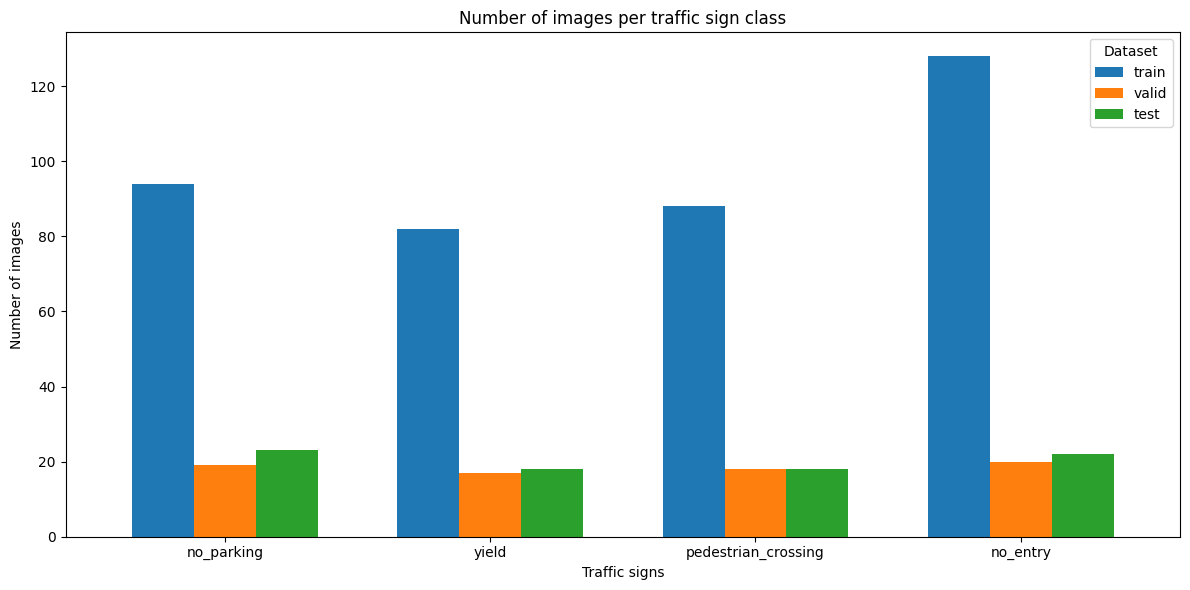

In [3]:
from collections import Counter
import pandas as pd
import os

def counter_files(path, row):
    counts = Counter()
    
    for file in os.listdir(path):
        path_file = os.path.join(path, file)
        with open(path_file , "r") as f:
            file_contents = f.read()
        if file_contents.strip() == "":
            continue
        for line in file_contents.splitlines():  
            class_id = int(line.split()[0])  
            counts[class_id] += 1
        
    return pd.DataFrame(counts, index=[row])

train_count = counter_files(train_labels, "train")
valid_count = counter_files(valid_labels, "valid")
test_count = counter_files(test_labels, "test")


sign_class_names = ["no_parking","pedestrian_crossing", "yield","no_entry"]

df_total = pd.concat([train_count,valid_count, test_count], axis=0).fillna(0)

df_total = df_total.T
df_total.index = [
    sign_class_names[i]
    for i in df_total.index
]
ax = df_total.plot(kind="bar", figsize=(12, 6), color=["#1f77b4", "#ff7f0e", "#2ca02c"], width=0.7)
ax.set_xlabel("Traffic signs")
ax.set_ylabel("Number of images")
ax.tick_params(axis="x", labelrotation=0)
ax.set_title("Number of images per traffic sign class")
ax.legend(title="Dataset")
ax.figure.tight_layout()

### Class Distribution Results

All four classes are represented in the three splits. `no_entry` has the largest training support, while validation and test contain relatively few annotations per class. Class-level scores are therefore needed to expose errors that a background-dominated accuracy can hide.

Annotation counts and ROI counts describe different populations. After proposal generation, one object can produce multiple ROIs or none; the later confusion-matrix supports should not be interpreted as the dataset's annotation distribution.

### Inspect Representative Training Images

Display selected examples of the four classes to examine their appearance, scale, viewpoint, and illumination. The displayed examples provide context for both proposal generation and classification.

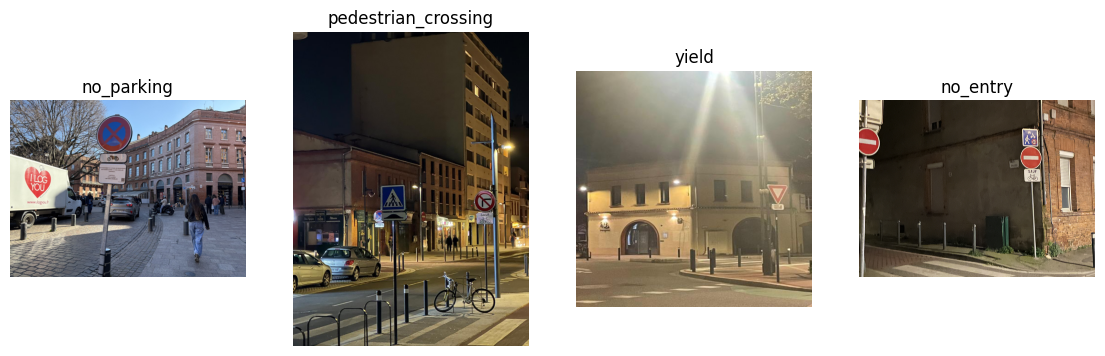

In [6]:
import random
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

plt.figure(figsize=(14,22))
classes = [273, 98, 72, 190]
for i in range(1,5) :
    c_path = os.path.join(data_train, f"img{classes[i-1]}*")
    c_path = glob.glob(c_path)
    img = Image.open(c_path[0])
    img = ImageOps.exif_transpose(img)
    plt.subplot(1,4,i)
    plt.imshow(img)
    plt.title(sign_class_names[i-1])
    plt.axis('off')
    i += 1
plt.show()    

### Image Inspection

The examples include both daytime and nighttime scenes, with changes in scale, viewing angle, glare, and background clutter. A single image can contain several signs or other salient objects. These examples motivate checking proposal localization and sign classification separately rather than treating image-level appearance as sufficient evidence of detection quality.

## 2. Build the COCO-Pretrained RPN

`My_RPN` reuses the image transform, ResNet-50/FPN backbone, RPN, and RoI Align module of a pretrained Faster R-CNN. The RPN predicts anchor objectness and box offsets; it does not predict traffic sign categories.

`objectness_thresh` filters proposal scores, while `nms_thresh` suppresses overlapping decoded proposals within each FPN level. BG/FG IoU thresholds determine negative, ignored, and positive anchor targets, subject to the RPN matcher's best-match rules.

An NMS threshold of `0.0` is aggressive suppression, not a switch that disables NMS. Per-level NMS can leave overlapping boxes from different FPN levels; the classifier pipeline adds a global NMS stage to compare them.

In [3]:
import torch.nn as nn
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights

class My_RPN(nn.Module):
    def __init__(self, nms_thresh=0.0, objectness_thresh=0.0, fg_iou=0.7, bg_iou=0.3):
        super().__init__()

        self.nms_thresh = nms_thresh
        self.objectness_thresh = objectness_thresh
        self.fg_iou = fg_iou
        self.bg_iou = bg_iou
        base_model = fasterrcnn_resnet50_fpn(
            weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT,
            min_size=640,
            max_size=4000,
            rpn_nms_thresh= nms_thresh,   # Suppress proposals that overlap too much
            rpn_score_thresh=objectness_thresh,  # Minimum objectness score threshold
            rpn_fg_iou_thresh=fg_iou,
            rpn_bg_iou_thresh=bg_iou
        )

        self.preprocessor = base_model.transform
        self.backbone = base_model.backbone
        self.rpn = base_model.rpn
        self.roi_align = base_model.roi_heads.box_roi_pool

    def forward(self, images, targets=None, return_roi_features=True):
        images, targets = self.preprocessor(images, targets)
        features = self.backbone(images.tensors)
        proposals, rpn_losses = self.rpn(images, features, targets)
        # Computing RPN losses does not require ROI features.
        if not return_roi_features:
            return None, rpn_losses
        roi_features = self.roi_align(
            features,
            proposals,
            images.image_sizes
        )
        return roi_features, rpn_losses


## 3. Load Images and Prepare Detection Batches

`Traffic_sign` pairs each image with its annotation file and reads normalized YOLO boxes in `(center_x, center_y, width, height)` format. Empty label files represent images without annotated objects.

The loader applies `ImageOps.exif_transpose` before tensor conversion. This incorporates the orientation handling introduced after inspecting rotated images and misplaced boxes. Annotation coordinates must describe the same oriented image used by the detector.

Transforms convert images to tensors without random augmentation. `collate_fn` retains images and annotations as lists, accommodating different image sizes and object counts. Training uses shuffled batches; validation keeps a fixed order. The initial batch size is 16 images.

In [4]:
from torch.utils.data import Dataset
from PIL import Image

class Traffic_sign(Dataset):
    def __init__(self, images_dir, labels_dir, transform=None):
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.images_files = sorted(os.listdir(images_dir))
        self.transform = transform

    def __len__(self):
        return len(self.images_files)

    def __getitem__(self, idx):
        image_name = self.images_files[idx]
        img_path = os.path.join(self.images_dir, image_name)
        # Match each image to the .txt file with the same name.
        label_path = os.path.join(self.labels_dir, os.path.splitext(image_name)[0] + ".txt")
        with Image.open(img_path) as img:
            image = img.convert("RGB")
            image = ImageOps.exif_transpose(image)
        if self.transform is not None:
            image = self.transform(image)

        with open(label_path, "r") as f:
            lines = [line.split() for line in f if line.strip()]

        labels = None
        if lines:
            labels = {
                "label": [int(line[0]) for line in lines],
                "bbox": [[float(x) for x in line[1:]] for line in lines],
            }
        return image, labels
    

In [5]:
from torch.utils.data import DataLoader
from torchvision import transforms


transform_train = transforms.Compose([
    transforms.ToTensor(),
])

transform_valid = transforms.ToTensor()

def collate_fn(batch):
    images, targets = zip(*batch)
    return list(images), list(targets)

dataset_train = Traffic_sign(data_train, train_labels, transform=transform_train)
dataset_valid = Traffic_sign(data_valid, valid_labels, transform=transform_valid)

batch_size = 16
dataloader_train = DataLoader(
    dataset_train, batch_size=batch_size, shuffle=True, collate_fn=collate_fn
)
dataloader_val = DataLoader(
    dataset_valid, batch_size=batch_size, shuffle=False, collate_fn=collate_fn
)


### Target Conversion and Anchor Metrics

`prepare_targets` converts normalized boxes into pixel `(x1, y1, x2, y2)` coordinates, clips boxes to the image, removes invalid boxes, and shifts sign IDs to `1..4`. The detector transform then resizes each image and its targets together.

`objectness_confusion_matrix` compares thresholded anchor logits with the RPN matcher's target labels. Ignored anchors are excluded. Rows represent true background/object labels and columns represent predictions.

- **Recall:** `TP / (TP + FN)` over positive anchors.
- **Precision:** `TP / (TP + FP)` over anchors predicted as objects.
- **F1:** `2 × TP / (2 × TP + FP + FN)`.

This evaluation occurs before box regression and NMS. Its false negatives are anchors, not missed traffic sign instances; changing only NMS cannot change this matrix.

In [6]:
import torch.optim as optim
from torchvision.ops import box_convert
from tqdm.auto import tqdm
from torchvision.models.detection.rpn import concat_box_prediction_layers


def prepare_targets(images, annotations):
    targets = []
    for image, annotation in zip(images, annotations):
        height, width = image.shape[-2:]
        if annotation is None:
            boxes = torch.empty((0, 4), dtype=torch.float32, device=image.device)
            labels = torch.empty((0,), dtype=torch.int64, device=image.device)
        else:
            boxes = torch.as_tensor(
                annotation["bbox"], dtype=torch.float32, device=image.device
            ).reshape(-1, 4)
            boxes = box_convert(boxes, in_fmt="cxcywh", out_fmt="xyxy")
            boxes = boxes * boxes.new_tensor([width, height, width, height])
            # Torchvision convention: 0 = background, traffic sign classes = 1 to 4.
            labels = torch.as_tensor(
                annotation["label"], dtype=torch.int64, device=image.device
            ) + 1

            boxes[:, 0::2].clamp_(0, width)
            boxes[:, 1::2].clamp_(0, height)
            valid = (boxes[:, 2] > boxes[:, 0]) & (boxes[:, 3] > boxes[:, 1])
            boxes, labels = boxes[valid], labels[valid]

        targets.append({"boxes": boxes, "labels": labels})
    return targets


def run_Detector(dataloader):
    model.eval()

    running_loss = 0.0
    image_count = 0
    with torch.no_grad() :
        for images, annotations in tqdm(dataloader, desc="Evaluation"):
            images = [image.to(device) for image in images]
            targets = prepare_targets(images, annotations)

            _, loss_dict = model(images, targets, return_roi_features=False)
            loss = sum(loss_dict.values())

            running_loss += loss * len(images)
            image_count += len(images)

    if image_count == 0:
        raise ValueError("The DataLoader contains no images.")
    return running_loss / image_count



# Binary ANCHOR objectness matrix, before box regression and NMS.
# The RPN does not predict the four traffic sign classes.
# This matrix does not measure the localization quality of the proposed boxes.
def objectness_confusion_matrix(model, dataloader):
    model.eval()
    device = next(model.parameters()).device
    confusion = torch.zeros((2, 2), dtype=torch.int64)
    ignored_count = 0
    with torch.no_grad():
        for images, annotations in dataloader:
            images = [image.to(device) for image in images]
            targets = prepare_targets(images, annotations)
            image_list, targets = model.preprocessor(images, targets)
            features = list(model.backbone(image_list.tensors).values())
            # logits_per_level : list of tensors, one per FPN level (A), shape (N, A, H, W)
            # deltas_per_level : list of tensors, one per FPN level (A), shape (N, A * 4, H, W)
            logits_per_level, deltas_per_level = model.rpn.head(features)
            # anchors : list of tensors, one per FPN level (A), shape (N, A * 4, H, W)
            anchors = model.rpn.anchor_generator(image_list, features)
            # logits : tensor of shape (N, A, H, W), objectness scores for each anchor
            logits, _ = concat_box_prediction_layers(logits_per_level, deltas_per_level)

            # Use the same IoU-based target assignment as during training:
            # Positive, negative, or ignored (-1), following the RPN rules.
            anchor_labels, _ = model.rpn.assign_targets_to_anchors(anchors, targets)
            truth = torch.cat(anchor_labels)
            keep = truth >= 0
            ignored_count += int((~keep).sum().item())
            truth = truth[keep].to(torch.int64)
            predicted = (logits.flatten()[keep].sigmoid() >= model.objectness_thresh).to(torch.int64)
            confusion += torch.bincount(
                2 * truth + predicted, minlength=4
            ).reshape(2, 2).cpu()
    return confusion.numpy(), ignored_count

## 4. Explore the Pretrained RPN

Evaluate 12 combinations of objectness thresholds `[0.3, 0.7, 0.8, 0.9]` and BG/FG pairs `[(0.1, 0.9), (0.25, 0.75), (0.4, 0.6)]`. Every configuration uses the original COCO weights and runs on `dataloader_train` without weight updates.

The sweep is an exploratory anchor evaluation. Lowering the objectness threshold changes the prediction trade-off, while changing BG/FG also changes the targets and ignored-anchor population. The resulting ranking does not directly measure proposal localization quality.

Settings, confusion matrices, and ignored-anchor counts are saved in `objectness_confusion_matrix_results.pt`.

In [11]:
import gc
from itertools import product
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
param_objectness = [0.3, 0.7, 0.8, 0.9]
param_iou = [(0.1,0.9), (0.25, 0.75), (0.4,0.6)]
results = []

combinations = list(product(param_objectness, param_iou))
for score_obj, (bg, fg) in tqdm(combinations, desc="Sweep objectness / IoU"):
        model = My_RPN(objectness_thresh=score_obj, bg_iou=bg, fg_iou = fg).to(device)
        confusion, ignored_count = objectness_confusion_matrix(model, dataloader_train)
        results.append({
            "objectness_thresh": score_obj,
            "bg_iou": bg,
            "fg_iou": fg,
            "confusion_matrix": confusion,
            "ignored_count": ignored_count
        })
        del model               
        gc.collect()            
        if device.type == 'cuda':
            torch.cuda.empty_cache()

torch.save(results, "objectness_confusion_matrix_results.pt")

Sweep objectness / IoU:   0%|          | 0/12 [00:00<?, ?it/s]

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth



  0%|          | 0.00/160M [00:00<?, ?B/s]
  6%|▌         | 8.88M/160M [00:00<00:01, 92.8MB/s]
 20%|█▉        | 31.6M/160M [00:00<00:00, 178MB/s] 
 32%|███▏      | 51.8M/160M [00:00<00:00, 193MB/s]
 45%|████▌     | 72.2M/160M [00:00<00:00, 201MB/s]
 58%|█████▊    | 92.9M/160M [00:00<00:00, 206MB/s]
 73%|███████▎  | 116M/160M [00:00<00:00, 220MB/s] 
100%|██████████| 160M/160M [00:00<00:00, 205MB/s]
Sweep objectness / IoU: 100%|██████████| 12/12 [12:42<00:00, 63.51s/it]


### Display the Pretrained Anchor Baseline

Load the saved results and display recall, precision, F1, false negatives, false positives, and ignored anchors. Rows are sorted by recall and then F1. Compare scores together with their objectness and BG/FG settings.

In [12]:
import pandas as pd
import numpy as np

# 1. Extract and compute metrics from 'results'
table_rows = []

#results = torch.load(f"{saving_dir}/objectness_confusion_matrix_results.pt", weights_only=False)
for res in results:
    conf = res["confusion_matrix"]
    
    # Matrix structure: 
    # conf[0,0] = True Negatives (Background predicted as Background)
    # conf[0,1] = False Positives (Background predicted as Object)
    # conf[1,0] = False Negatives (Object predicted as Background)
    # conf[1,1] = True Positives (Object predicted as Object)
    tn, fp = conf[0, 0], conf[0, 1]
    fn, tp = conf[1, 0], conf[1, 1]
    
    # Compute metrics with division-by-zero guards
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    
    table_rows.append({
        "Objectness": res["objectness_thresh"],
        "IoU (BG - FG)": f"{res['bg_iou']} - {res['fg_iou']}",
        "Recall": recall,
        "Precision": precision,
        "F1-Score": f1_score,
        "False Negatives (FN)": int(fn),
        "False Positives (FP)": int(fp),
        "Ignored Anchors": res["ignored_count"]
    })

# 2. Create the pandas DataFrame
df = pd.DataFrame(table_rows)

# 3. Sort by recall, then F1-score, in descending order
df = df.sort_values(by=["Recall", "F1-Score"], ascending=[False, False])

# 4. Apply heatmap styling
styled_table = (
    df.style
    # Format numbers: percentages for scores and thousands separators for anchors
    .format({
        "Recall": "{:.2%}",
        "Precision": "{:.2%}",
        "F1-Score": "{:.2%}",
        "False Negatives (FN)": "{:,}",
        "False Positives (FP)": "{:,}",
        "Ignored Anchors": "{:,}"
    })
    # Red (0%) to green (100%) gradient for performance metrics
    .background_gradient(subset=["Recall", "Precision", "F1-Score"], cmap="RdYlGn", vmin=0, vmax=1)
    
    # Yellow (low) to red (high) gradient for errors (lower is better)
    .background_gradient(subset=["False Negatives (FN)", "False Positives (FP)"], cmap="YlOrRd")
    
    # Blue gradient for ignored anchors (for information only)
    .background_gradient(subset=["Ignored Anchors"], cmap="Blues")
    
    # Table caption
    .set_caption("RPN Hyperparameter Evaluation (Sorted by Recall)")
)

# 5. Display by referencing the variable at the end of a Jupyter/Kaggle cell
styled_table

,Objectness,IoU (BG - FG),Recall,Precision,F1-Score,False Negatives (FN),False Positives (FP),Ignored Anchors
1,0.300000,0.25 - 0.75,69.47%,0.16%,0.32%,457,"639,706","112,573"
0,0.300000,0.1 - 0.9,69.40%,0.15%,0.29%,411,"634,112","455,723"
2,0.300000,0.4 - 0.6,63.17%,0.32%,0.64%,"1,210","642,726","26,959"
4,0.700000,0.25 - 0.75,61.46%,0.26%,0.52%,577,"354,821","112,573"
3,0.700000,0.1 - 0.9,61.43%,0.23%,0.46%,518,"353,657","455,766"
6,0.800000,0.1 - 0.9,59.79%,0.28%,0.55%,540,"287,738","455,724"
7,0.800000,0.25 - 0.75,59.72%,0.31%,0.61%,603,"289,184","112,573"
10,0.900000,0.25 - 0.75,55.04%,0.40%,0.79%,673,"206,586","112,573"
9,0.900000,0.1 - 0.9,54.80%,0.36%,0.71%,607,"205,782","455,788"
5,0.700000,0.4 - 0.6,54.40%,0.50%,0.99%,"1,498","357,274","26,959"


### Pretrained RPN Results

The highest displayed anchor recall is **69.47%**, obtained with objectness **0.3** and BG/FG **0.25/0.75**. Its precision is **0.16%** and F1 is **0.32%**. With the same BG/FG pair and objectness **0.8**, recall decreases to **59.72%**, while precision increases to **0.31%**.

These rows show the objectness trade-off: a more permissive threshold recovers more positive anchors but also admits more negatives. The very large false-positive counts concern all evaluated anchors and cannot be read as numbers of false detected signs.

The next stage adapts the RPN to the dataset and repeats the evaluation. Its IoU grid introduces `(0.2, 0.8)` in place of `(0.4, 0.6)`, so only shared settings have a matching baseline in this table.

## 5. Fine-Tune 12 RPN Configurations

Train objectness thresholds `[0.3, 0.7, 0.8, 0.9]` with BG/FG pairs `[(0.1, 0.9), (0.25, 0.75), (0.2, 0.8)]`. Two independent workers on `cuda:0` and `cuda:1` take configurations from a shared queue. Each run starts from COCO weights with the backbone frozen and in evaluation mode.

SGD updates only the RPN parameters, using learning rate `0.001`, momentum `0.9`, and weight decay `0.0005`. Training minimizes `loss_objectness + loss_rpn_box_reg` for up to 30 epochs. The RPN losses use sampled anchors; objectness filtering itself is a proposal setting.

Validation disables gradients while keeping the RPN in training mode to expose its losses. `ReduceLROnPlateau` halves the learning rate after a plateau. Early stopping uses five epochs without an improvement exceeding `0.001`, and the loop also stops at learning rate `1e-6`.

Each run keeps an independent CPU copy of the weights with the lowest validation loss, plus its epoch and loss histories. Individual configuration files are merged in configuration order into `rpnS_finetuned.pt`.

In [ ]:
import gc
import sys
import torch
import torch.optim as optim

from pathlib import Path
from itertools import product
from queue import Queue, Empty
from threading import Event, Lock
from concurrent.futures import ThreadPoolExecutor, as_completed
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm


# Requires two GPUs.
gpu_devices = ["cuda:0", "cuda:1"]

param_objectness = [0.3, 0.7, 0.8, 0.9]
param_iou = [(0.1,0.9), (0.25, 0.75), (0.2,0.8)]

num_epochs = 30
min_delta = 0.001
min_lr_threshold = 1e-6
patience = 5

output_dir = Path("/kaggle/working")
output_dir.mkdir(parents=True, exist_ok=True)
checkpoint_path = output_dir / "rpnS_finetuned.pt"

configs = [
    {
        "objectness_thresh": float(score),
        "bg_iou": float(bg),
        "fg_iou": float(fg),
    }
    for score, (bg, fg) in product(param_objectness, param_iou)
]

jobs = Queue()
for index, config in enumerate(configs):
    jobs.put((index, config))

stop_event = Event()
model_init_lock = Lock()


def run_epoch(model, dataloader, training, optimizer=None):
    if training and optimizer is None:
        raise ValueError("An optimizer is required for training.")

    # Each model uses its own GPU.
    model_device = next(model.parameters()).device

    model.train(training)
    model.backbone.eval()
    model.rpn.train()  # Required to return losses during validation.

    running_loss = 0.0
    image_count = 0

    try:
        with torch.set_grad_enabled(training):
            for images, annotations in dataloader:
                if stop_event.is_set():
                    raise RuntimeError(
                        "Stopping after a worker failed or execution was interrupted."
                    )

                images = [image.to(model_device) for image in images]
                targets = prepare_targets(images, annotations)

                if training:
                    optimizer.zero_grad(set_to_none=True)

                _, losses = model(
                    images, targets, return_roi_features=False
                )
                loss = (
                    losses["loss_objectness"]
                    + losses["loss_rpn_box_reg"]
                )

                if not torch.isfinite(loss):
                    raise RuntimeError(f"Non-finite loss: {losses}")

                if training:
                    loss.backward()
                    optimizer.step()

                running_loss += loss.item() * len(images)
                image_count += len(images)
    finally:
        model.eval()

    if image_count == 0:
        raise ValueError("The DataLoader contains no images.")

    return running_loss / image_count


def gpu_worker(device_name, position):
    completed = []

    try:
        with torch.cuda.device(device_name):
            # Each worker owns its DataLoaders.
            train_loader = DataLoader(
                dataset_train,
                batch_size=dataloader_train.batch_size,
                shuffle=True,
                collate_fn=collate_fn,
                num_workers=0,
            )
            val_loader = DataLoader(
                dataset_valid,
                batch_size=dataloader_val.batch_size,
                shuffle=False,
                collate_fn=collate_fn,
                num_workers=0,
            )

            while not stop_event.is_set():
                try:
                    index, config = jobs.get_nowait()
                except Empty:
                    break

                # Avoid simultaneous downloads of pretrained weights.
                with model_init_lock:
                    model = My_RPN(**config).to(device_name)

                model.backbone.requires_grad_(False)

                optimizer = optim.SGD(
                    model.rpn.parameters(),
                    lr=0.001,
                    momentum=0.9,
                    weight_decay=0.0005,
                )
                scheduler = ReduceLROnPlateau(
                    optimizer,
                    mode="min",
                    factor=0.5,
                    patience=2,
                    threshold=min_delta,
                    threshold_mode="abs",
                )

                result = {**config, "loss_T": [], "loss_V": []}
                config_path = output_dir / f"rpn_config_{index:02d}.pt"

                best_loss = float("inf")
                patience_reference = float("inf")
                epochs_without_improvement = 0

                try:
                    with tqdm(
                        range(num_epochs),
                        desc=f"{device_name} | config {index + 1}/{len(configs)}",
                        position=position,
                        file=sys.stdout,
                    ) as epochs:
                        for epoch in epochs:
                            train_loss = run_epoch(
                                model, train_loader, True, optimizer
                            )
                            val_loss = run_epoch(
                                model, val_loader, False
                            )

                            result["loss_T"].append(train_loss)
                            result["loss_V"].append(val_loss)

                            # Keep an independent CPU copy of the best weights.
                            if val_loss < best_loss:
                                best_loss = val_loss
                                state = model.state_dict()

                                for name, tensor in state.items():
                                    state[name] = tensor.detach().cpu().clone()

                                result.update(
                                    checkpoints=state,
                                    best_val_loss=val_loss,
                                    best_epoch=epoch + 1,
                                )

                            if val_loss < patience_reference - min_delta:
                                patience_reference = val_loss
                                epochs_without_improvement = 0
                            else:
                                epochs_without_improvement += 1

                            scheduler.step(val_loss)
                            current_lr = optimizer.param_groups[0]["lr"]

                            epochs.set_postfix(
                                train=f"{train_loss:.5f}",
                                val=f"{val_loss:.5f}",
                                lr=f"{current_lr:.2e}",
                            )

                            # Different configurations write different files.
                            torch.save(result, config_path)

                            if epochs_without_improvement >= patience:
                                break
                            if current_lr <= min_lr_threshold:
                                break

                    completed.append((index, config_path))
                    tqdm.write(
                        f"{device_name}: saved {config_path.name} | "
                        f"best epoch={result['best_epoch']}"
                    )

                finally:
                    del model, optimizer, scheduler
                    gc.collect()
                    torch.cuda.empty_cache()

    except BaseException:
        stop_event.set()
        raise

    return completed


# Start one worker per GPU.
completed = []

with ThreadPoolExecutor(max_workers=len(gpu_devices)) as executor:
    futures = [
        executor.submit(gpu_worker, device_name, position)
        for position, device_name in enumerate(gpu_devices)
    ]

    try:
        for future in as_completed(futures):
            completed.extend(future.result())
    except BaseException:
        stop_event.set()
        raise


# Merge results in the original configuration order.
# Only the main thread writes this file.
results = [
    torch.load(path, map_location="cpu", weights_only=True)
    for _, path in sorted(completed)
]

torch.save(results, checkpoint_path)
print(f"Saved {len(results)} configurations to {checkpoint_path}")

## 6. Re-evaluate Fine-Tuned RPNs on Training Data

Restore the saved configurations and recompute their anchor matrices on `dataloader_train`. The results are saved in `objectness_confusion_matrix_newresults.pt`.

This compares pretrained and fine-tuned weights on the same training split for settings shared by both sweeps. The shuffled loader does not guarantee identical batch composition between runs. A separate validation comparison follows to check the effect beyond training images.

In [ ]:
import gc
from itertools import product
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#results = torch.load(f"{saving_dir}/rpnS_finetuned.pt", weights_only=False)
param_objectness = [0.3, 0.7, 0.8, 0.9]
param_iou = [(0.1,0.9), (0.25, 0.75), (0.2,0.8)]
table = []
combinations = list(product(param_objectness, param_iou))
idx = 0
for score_obj, (bg, fg) in tqdm(combinations, desc="Sweep objectness / IoU"):
    model = My_RPN(objectness_thresh=score_obj, bg_iou=bg, fg_iou = fg).to(device)
    model.load_state_dict(results[idx]['checkpoints'])
    confusion, ignored_count = objectness_confusion_matrix(model, dataloader_train)
    table.append({
        "objectness_thresh": score_obj,
        "bg_iou": bg,
        "fg_iou": fg,
        "confusion_matrix": confusion,
        "ignored_count": ignored_count
    })
    del model               
    gc.collect()            
    if device.type == 'cuda':
        torch.cuda.empty_cache()
    idx += 1


torch.save(table, "objectness_confusion_matrix_newresults.pt")

### Display Fine-Tuned Anchor Metrics

Derive the same anchor precision, recall, F1, and error counts as in the pretrained table. Pair rows with identical objectness and BG/FG settings; the fine-tuned `(0.2, 0.8)` rows have no corresponding pretrained rows in the stored baseline.

In [10]:
import pandas as pd
import numpy as np

table = torch.load(f"{saving_dir}/objectness_confusion_matrix_finetuned.pt", weights_only=False)

# 1. Extract and compute metrics from 'results'
table_rows = []

for res in table:
    conf = res["confusion_matrix"]
    
    # Matrix structure: 
    # conf[0,0] = True Negatives (Background predicted as Background)
    # conf[0,1] = False Positives (Background predicted as Object)
    # conf[1,0] = False Negatives (Object predicted as Background)
    # conf[1,1] = True Positives (Object predicted as Object)
    tn, fp = conf[0, 0], conf[0, 1]
    fn, tp = conf[1, 0], conf[1, 1]
    
    # Compute metrics with division-by-zero guards
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    
    table_rows.append({
        "Objectness": res["objectness_thresh"],
        "IoU (BG - FG)": f"{res['bg_iou']} - {res['fg_iou']}",
        "Recall": recall,
        "Precision": precision,
        "F1-Score": f1_score,
        "False Negatives (FN)": int(fn),
        "False Positives (FP)": int(fp),
        "Ignored Anchors": res["ignored_count"]
    })

# 2. Create the pandas DataFrame
df = pd.DataFrame(table_rows)

# 3. Sort by recall, then F1-score, in descending order
df = df.sort_values(by=["Recall", "F1-Score"], ascending=[False, False])

# 4. Apply heatmap styling
styled_table = (
    df.style
    # Format numbers: percentages for scores and thousands separators for anchors
    .format({
        "Recall": "{:.2%}",
        "Precision": "{:.2%}",
        "F1-Score": "{:.2%}",
        "False Negatives (FN)": "{:,}",
        "False Positives (FP)": "{:,}",
        "Ignored Anchors": "{:,}"
    })
    # Red (0%) to green (100%) gradient for performance metrics
    .background_gradient(subset=["Recall", "Precision", "F1-Score"], cmap="RdYlGn", vmin=0, vmax=1)
    
    # Yellow (low) to red (high) gradient for errors (lower is better)
    .background_gradient(subset=["False Negatives (FN)", "False Positives (FP)"], cmap="YlOrRd")
    
    # Blue gradient for ignored anchors (for information only)
    .background_gradient(subset=["Ignored Anchors"], cmap="Blues")
    
    # Table caption
    .set_caption("RPN Hyperparameter Evaluation (Sorted by Recall)")
)

# 5. Display by referencing the variable at the end of a Jupyter/Kaggle cell
styled_table

,Objectness,IoU (BG - FG),Recall,Precision,F1-Score,False Negatives (FN),False Positives (FP),Ignored Anchors
1,0.300000,0.25 - 0.75,92.79%,0.29%,0.58%,108,"478,504","112,573"
0,0.300000,0.1 - 0.9,92.48%,0.27%,0.54%,101,"461,176","455,781"
2,0.300000,0.2 - 0.8,90.23%,0.23%,0.46%,134,"539,487","176,724"
4,0.700000,0.25 - 0.75,87.84%,0.73%,1.45%,182,"178,222","112,573"
3,0.700000,0.1 - 0.9,86.22%,0.57%,1.13%,185,"202,434","455,743"
8,0.800000,0.2 - 0.8,84.32%,0.92%,1.82%,215,"124,213","176,716"
7,0.800000,0.25 - 0.75,84.30%,0.84%,1.67%,235,"148,210","112,573"
5,0.700000,0.2 - 0.8,81.11%,0.41%,0.82%,259,"267,929","176,718"
6,0.800000,0.1 - 0.9,79.82%,0.60%,1.20%,271,"176,216","455,731"
10,0.900000,0.25 - 0.75,79.69%,1.57%,3.08%,304,"74,676","112,573"


### Fine-Tuning Results on the Training Split

For BG/FG **0.25/0.75**, fine-tuning improves both candidate objectness settings:

| Objectness | Pretrained recall | Fine-tuned recall | Pretrained F1 | Fine-tuned F1 | False negatives, before → after |
| --- | --- | --- | --- | --- | --- |
| 0.3 | 69.47% | 92.79% | 0.32% | 0.58% | 457 → 108 |
| 0.8 | 59.72% | 84.30% | 0.61% | 1.67% | 603 → 235 |

False positives also decrease: **639,706 → 478,504** at objectness 0.3 and **289,184 → 148,210** at objectness 0.8. The RPN has therefore adapted on the training split, with the more selective setting retaining fewer false-positive anchors. These measurements remain anchor statistics; validation is used next to compare the two retained candidates.

## 7. Compare Pretrained and Fine-Tuned RPNs on Validation

Select the two configurations with objectness **0.3** or **0.8**, both using BG/FG **0.25/0.75**. For each configuration, evaluate the original COCO weights and the matching fine-tuned checkpoint on the same `dataloader_val`, with unchanged objectness and anchor-label settings.

Recall gains are absolute percentage-point differences. Validation was also used to select checkpoints, so this comparison informs model selection rather than serving as an independent final test.

In [13]:
# Compare before and after fine-tuning on the same validation images.
# Anchor metrics, before box regression and NMS.
import gc
import sys

import numpy as np
import pandas as pd
import torch
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. On charge directement le fichier sauvegardé par le script précédent
validation_checkpoint_path = f"{saving_dir}/rpnS_finetuned.pt"
#validation_checkpoint_path = "/kaggle/working/rpnS_finetuned.pt"
checkpoints_val = torch.load(
    validation_checkpoint_path, map_location="cpu", weights_only=True
)

val_comparison = []
val_matrices = []

# On détermine le total exact pour l'affichage de la barre de progression
num_valid_configs = sum(
    1 for ckpt in checkpoints_val 
    if float(ckpt["objectness_thresh"]) in (0.3, 0.8) 
    and float(ckpt["bg_iou"]) == 0.25 
    and float(ckpt["fg_iou"]) == 0.75
)

with tqdm(
    total=2 * num_valid_configs,
    desc="Validation comparison",
    file=sys.stdout,
) as val_progress:
    for checkpoint_val in checkpoints_val:
        
        # --- CONDITIONS DE SKIP ---
        obj = float(checkpoint_val["objectness_thresh"])
        bg = float(checkpoint_val["bg_iou"])
        fg = float(checkpoint_val["fg_iou"])
        
        if not (obj in (0.3, 0.8) and bg == 0.25 and fg == 0.75):
            # On vide explicitement la clé des poids pour libérer la RAM immédiatement
            checkpoint_val.pop("checkpoints", None) 
            continue 
        # ---------------------------

        config_val = {
            name: float(checkpoint_val[name])
            for name in ("objectness_thresh", "bg_iou", "fg_iou")
        }

        # Keep one model in GPU memory for each before/after pair.
        model_val = My_RPN(**config_val).to(device)
        
        try:
            for version_val in ("Pretrained", "Fine-tuned"):
                if version_val == "Fine-tuned":
                    # On charge les poids entraînés stockés dans "checkpoints"
                    model_val.load_state_dict(checkpoint_val["checkpoints"])

                val_progress.set_postfix(
                    model=version_val,
                    bg=config_val["bg_iou"],
                    fg=config_val["fg_iou"],
                )
                
                confusion_val, ignored_val = objectness_confusion_matrix(
                    model_val, dataloader_val,
                )
                
                val_matrices.append({
                    **config_val,
                    "model": version_val,
                    "confusion_matrix": confusion_val,
                    "ignored_count": ignored_val,
                })
                
                tn_val, fp_val, fn_val, tp_val = map(int, confusion_val.ravel())
                recall_val = tp_val / (tp_val + fn_val) if tp_val + fn_val else 0.0
                precision_val = tp_val / (tp_val + fp_val) if tp_val + fp_val else 0.0
                f1_val = (
                    2 * precision_val * recall_val / (precision_val + recall_val)
                    if precision_val + recall_val else 0.0
                )
                
                if version_val == "Pretrained":
                    recall_initial_val = recall_val

                val_comparison.append({
                    "Objectness": config_val["objectness_thresh"],
                    "IoU (BG - FG)": f"{config_val['bg_iou']:g} - {config_val['fg_iou']:g}",
                    "Model": version_val,
                    "Recall": recall_val,
                    "Precision": precision_val,
                    "F1-Score": f1_val,
                    "False Negatives (FN)": fn_val,
                    "False Positives (FP)": fp_val,
                    "Ignored Anchors": int(ignored_val),
                    "Recall gain (points)": (
                        100 * (recall_val - recall_initial_val)
                        if version_val == "Fine-tuned" else np.nan
                    ),
                })
                val_progress.update(1)
        finally:
            del model_val
            # Libérer la config en mémoire une fois évaluée
            checkpoint_val.pop("checkpoints", None) 
            gc.collect()
            if device.type == "cuda":
                torch.cuda.empty_cache()

# Nettoyage final de la grosse liste
del checkpoints_val
gc.collect()

# Keep the before/after rows together for each configuration.
df_val_comparison = pd.DataFrame(val_comparison)
styled_val_comparison = (
    df_val_comparison.style
    .format({
        "Objectness": "{:.1f}",
        "Recall": "{:.2%}",
        "Precision": "{:.2%}",
        "F1-Score": "{:.2%}",
        "False Negatives (FN)": "{:,}",
        "False Positives (FP)": "{:,}",
        "Ignored Anchors": "{:,}",
        "Recall gain (points)": "{:+.2f}",
    }, na_rep="—")
    .background_gradient(
        subset=["Recall", "Precision", "F1-Score"],
        cmap="RdYlGn", vmin=0, vmax=1,
    )
    .set_caption(
        "Validation — pretrained / fine-tuned RPN: anchor objectness before NMS"
    )
    .hide(axis="index")
)

# Affichage du tableau final
styled_val_comparison

Validation comparison: 100%|██████████| 4/4 [00:58<00:00, 14.72s/it, bg=0.25, fg=0.75, model=Fine-tuned]


Objectness,IoU (BG - FG),Model,Recall,Precision,F1-Score,False Negatives (FN),False Positives (FP),Ignored Anchors,Recall gain (points)
0.3,0.25 - 0.75,Pretrained,69.00%,0.15%,0.29%,71,"107,424","23,489",—
0.3,0.25 - 0.75,Fine-tuned,95.63%,0.26%,0.52%,10,"83,968","23,489",+26.64
0.8,0.25 - 0.75,Pretrained,55.90%,0.26%,0.51%,101,"49,569","23,489",—
0.8,0.25 - 0.75,Fine-tuned,88.21%,0.74%,1.46%,27,"27,260","23,489",+32.31


### RPN Validation Results

The same improvement appears in the stored validation comparison:

| Objectness | Recall, before → after | Recall gain | F1, before → after | False negatives, before → after | False positives, before → after |
| --- | --- | --- | --- | --- | --- |
| 0.3 | 69.00% → 95.63% | +26.64 points | 0.29% → 0.52% | 71 → 10 | 107,424 → 83,968 |
| 0.8 | 55.90% → 88.21% | +32.31 points | 0.51% → 1.46% | 101 → 27 | 49,569 → 27,260 |

Gains use the values reported from the unrounded calculations. Both candidates improve recall while reducing false positives and false negatives. Objectness **0.3** gives higher anchor recall; **0.8** is more selective and gives higher anchor precision and F1.

Both settings are retained for the classifier experiments. A recall of 95.63% here describes positive anchors, not the fraction of traffic signs detected after proposal filtering.

### Export the Two Candidate RPNs

Reload `rpnS_finetuned.pt` and explicitly select the records with BG/FG `(0.25, 0.75)` and objectness `0.3` or `0.8`. Save both checkpoint dictionaries as a list in `My_Best_rpn.pt`.

Each record retains its own weights, parameters, best epoch, and training information. The classifier grid refers to these candidates using `detector_index`; the export is not an automatic selection of the last list entry.

In [ ]:


# On recharge le fichier complet (au cas où il ne serait plus en mémoire)
tous_les_checkpoints = torch.load("/kaggle/working/rpnS_finetuned.pt", map_location="cpu", weights_only=False)
#tous_les_checkpoints = torch.load(f"{saving_dir}/rpnS_finetuned.pt", map_location="cpu", weights_only=False)
# 2. On prépare un dictionnaire pour stocker nos deux favoris
mes_meilleurs_rpn = []

# 3. On extrait les deux configurations cibles
for ckpt in tous_les_checkpoints:
    obj = float(ckpt["objectness_thresh"])
    bg = float(ckpt["bg_iou"])
    fg = float(ckpt["fg_iou"])
    
    # Vérification que l'on est bien sur l'IoU optimal (0.25 - 0.75)
    if bg == 0.25 and fg == 0.75:
        if obj == 0.3:
            mes_meilleurs_rpn.append(ckpt)
            print("✅ Configuration Objectness 0.3 ajoutée.")
        elif obj == 0.8:
            mes_meilleurs_rpn.append(ckpt)
            print("✅ Configuration Objectness 0.8 ajoutée.")

# 4. On sauvegarde ce nouveau dictionnaire dans un fichier unique
torch.save(mes_meilleurs_rpn, "/kaggle/working/My_Best_rpn.pt")
print("🚀 Fichier 'My_Best_rpn.pt' créé avec succès !")

## 8. Build the Custom ROI Classifier

`faster_R_CNN` freezes the complete detector. Its RPN supplies regressed proposals after per-level NMS, and an additional global NMS compares proposals from different FPN levels within each image using their objectness scores. Setting the global threshold to `None` skips that extra stage; setting it to `0.0` suppresses positive overlap aggressively.

RoI Align extracts a `256 × 7 × 7` feature tensor for each retained box. The custom CNN applies convolutions, activations, pooling, and a linear layer to produce five logits. The backbone processes the image; the CNN head classifies pooled ROI features. This head adds no second box-regression stage.

For supervision, a proposal receives its highest-IoU annotation's class when IoU is at least **0.75**; otherwise its target is background. This `roi_iou_threshold` applies to decoded proposals and is distinct from the RPN's BG/FG anchor thresholds.

All returned proposals are used without foreground/background subsampling. Their class distribution is handled through weighted cross-entropy.

In [7]:
from torchvision.ops import box_iou, nms
from torchvision.models.detection.rpn import concat_box_prediction_layers

class faster_R_CNN(nn.Module) :
    def __init__(self, detector=None, roi_iou_threshold=0.75, global_nms_threshold=None):
        super().__init__()

        self.main = nn.Sequential(
            # input: 256,7,7
            nn.Conv2d(256, 128, kernel_size=3, stride=1, padding=1),
            nn.ELU(),
            nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=1),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),  # output: 64,4,4
            nn.Conv2d(64, 32, kernel_size=3, stride=1, padding=1),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1), # output: 32,2,2
            nn.Conv2d(32, 8, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1), # output: 8,1,1
            nn.Flatten(),
            nn.Linear(8, 5)) 
        if detector is None:
            raise ValueError("A trained RPN must be provided.")
        if global_nms_threshold is not None and not 0 <= global_nms_threshold <= 1:
            raise ValueError("Global NMS must be between 0 and 1, or None to disable it.")
        self.global_nms_threshold = global_nms_threshold
        self.roi_iou_threshold = roi_iou_threshold
        self.detector = detector
        self.detector.requires_grad_(False)  # The RPN is frozen during classifier training.   
        self.detector.eval()  # Keep the frozen detector in evaluation mode.

    def assign_roi_labels(self, proposals, targets):
        # One class per proposal, in the order expected by RoI Align.
        labels_per_image = []
        for boxes, target in zip(proposals, targets):
            # Without annotations, all proposals are labeled as background.
            labels = torch.zeros(len(boxes), dtype=torch.int64, device=boxes.device)
            if boxes.numel() > 0 and target["boxes"].numel() > 0:
                ious = box_iou(boxes, target["boxes"])  # (N_proposals, N_annotations)
                best_iou, matched_gt = ious.max(dim=1)  # (N_proposals,) each
                positive = best_iou >= self.roi_iou_threshold
                # prepare_targets has already converted classes to 1..4; background = 0.
                labels[positive] = target["labels"][matched_gt[positive]]
            labels_per_image.append(labels)
        return torch.cat(labels_per_image)  # (N_roi,), integers from 0 to 4

    @torch.no_grad()
    def get_proposals(self, images, targets=None):
        # Shared by ROI counting, training, validation, and inference.
        self.detector.eval()
        image_list, resized_targets = self.detector.preprocessor(images, targets)
        features = self.detector.backbone(image_list.tensors)

        if self.global_nms_threshold is None:
            # Preserve the behavior of checkpoints trained without global NMS.
            proposals, _ = self.detector.rpn(image_list, features, resized_targets)
        else:
            rpn = self.detector.rpn
            feature_list = list(features.values())
            logits_per_level, deltas_per_level = rpn.head(feature_list)
            anchors = rpn.anchor_generator(image_list, feature_list)
            anchors_per_level = [level[0].numel() for level in logits_per_level]
            logits, deltas = concat_box_prediction_layers(logits_per_level, deltas_per_level)
            decoded_boxes = rpn.box_coder.decode(deltas, anchors).reshape(len(anchors), -1, 4)
            proposals, scores = rpn.filter_proposals(
                decoded_boxes, logits, image_list.image_sizes, anchors_per_level,
            )
            # Global across FPN levels, but always separate for each image.
            proposals = [
                boxes[nms(boxes, image_scores, self.global_nms_threshold)]
                for boxes, image_scores in zip(proposals, scores)
            ]
        return features, proposals, resized_targets, image_list.image_sizes

    def forward(self, images, targets=None):
        with torch.no_grad():
            features, proposals, resized_targets, image_sizes = self.get_proposals(images, targets)
            roi_labels = None
            if resized_targets is not None:
                roi_labels = self.assign_roi_labels(proposals, resized_targets)
            # Global NMS has already removed proposals before RoI Align.
            roi_features = self.detector.roi_align(features, proposals, image_sizes)

        # Only the classifier builds a gradient graph.
        logits = self.main(roi_features)
        return logits, roi_labels


### Restore Models and Define Weighted Classifier Training

`load_rpn_candidates` reads the saved detector list; `load_rpn` restores one candidate and supplies the requested per-level NMS threshold. `load_classifier_checkpoint` restores the complete detector/CNN weights along with the saved thresholds.

Before training a classifier configuration, count training ROI labels after both NMS stages. For class `c`, the initial weight is `N / (C × n_c)`, where `N` is the total training ROI count, `C = 5`, and `n_c` is that class's ROI count. These counts describe proposals, not annotation totals.

`run_classifier_epoch` optimizes only the CNN during training and disables gradients during validation. It returns cross-entropy normalized by the sum of target-class weights. The training loop stores losses and checkpoints; confusion matrices are calculated afterward in separate evaluation cells.

In [8]:
# Train the classification CNN using the trained RPN.
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from pathlib import Path
from concurrent.futures import CancelledError
from torch.utils.data import DataLoader
from tqdm import tqdm
from torch.optim.lr_scheduler import ReduceLROnPlateau

def load_rpn_candidates(detector_path):
    candidates = torch.load(detector_path, map_location="cpu", weights_only=True)
    # Accept the earlier single-detector file as well as the new list.
    if isinstance(candidates, dict):
        candidates = [candidates]
    if not isinstance(candidates, (list, tuple)) or not candidates:
        raise ValueError("The detector file must contain at least one RPN checkpoint.")
    required = {"objectness_thresh", "bg_iou", "fg_iou", "checkpoints"}
    for detector_index, candidate in enumerate(candidates):
        if not isinstance(candidate, dict) or not required.issubset(candidate):
            raise ValueError(f"RPN checkpoint {detector_index} is missing weights or parameters.")
        if not candidate["checkpoints"]:
            raise ValueError(f"RPN checkpoint {detector_index} has no weights.")
    return candidates


def load_rpn(score_nms, detector_path, device=None, detector_index=0, rpn_candidates=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    device = torch.device(device)
    if rpn_candidates is None:
        rpn_candidates = load_rpn_candidates(detector_path)
    rpn_state = rpn_candidates[detector_index]
    detector = My_RPN(
        objectness_thresh=float(rpn_state["objectness_thresh"]),
        fg_iou=float(rpn_state["fg_iou"]),
        bg_iou=float(rpn_state["bg_iou"]),
        nms_thresh=float(score_nms),
    )
    # load_state_dict copies these shared CPU weights into an independent model.
    detector.load_state_dict(rpn_state["checkpoints"])
    return detector.to(device)


def load_classifier_checkpoint(saved_model, device):
    detector_config = {
        key: float(saved_model[key])
        for key in ("nms_thresh", "objectness_thresh", "bg_iou", "fg_iou")
    }
    model = faster_R_CNN(
        detector=My_RPN(**detector_config),
        roi_iou_threshold=float(saved_model["roi_iou_threshold"]),
        global_nms_threshold=saved_model.get("global_nms_threshold"),
    )
    model.load_state_dict(saved_model["checkpoints"])
    return model.to(device).eval()


@torch.no_grad()
def count_training_roi_labels(
    model, dataloader, class_names, description="Count training ROIs",
    position=None, stop_event=None, show_progress=True,
):
    model.eval()
    model_device = next(model.parameters()).device
    counts = torch.zeros(len(class_names), dtype=torch.int64)
    with tqdm(dataloader, desc=description, position=position,
              leave=False, file=sys.stdout, disable=not show_progress) as loop:
        for images, annotations in loop:
            if stop_event is not None and stop_event.is_set():
                raise CancelledError("ROI counting interrupted.")
            images = [image.to(model_device) for image in images]
            targets = prepare_targets(images, annotations)
            features, proposals, resized_targets, _ = model.get_proposals(images, targets)
            labels = model.assign_roi_labels(proposals, resized_targets)
            counts += torch.bincount(labels, minlength=len(class_names)).cpu()
            del features, proposals, resized_targets
    if counts.sum().item() == 0:
        raise ValueError("No training ROIs remain after proposal filtering.")
    missing = [name for name, count in zip(class_names, counts.tolist()) if count == 0]
    if missing:
        raise ValueError(
            f"No training ROIs for {missing}. Check proposal coverage, labels, and NMS before training."
        )
    return counts


def compute_class_weights(roi_counts):
    counts = torch.as_tensor(roi_counts, dtype=torch.float32)
    if counts.ndim != 1 or not torch.isfinite(counts).all() or (counts <= 0).any():
        raise ValueError("Each class must have a finite, positive training ROI count.")
    # Each class receives the same total weight across the counted training ROIs.
    return counts.sum() / (counts.numel() * counts)


def score_text(value):
    return "N/A" if value is None else f"{value:.2%}"


def run_classifier_epoch(
    model, dataloader, training, description, criterion, optimizer=None,
    position=None, stop_event=None, show_progress=True,
):
    if training and optimizer is None:
        raise ValueError("An optimizer is required to train the CNN.")
    if criterion.reduction != "mean" or criterion.weight is None:
        raise ValueError("Use CrossEntropyLoss with class weights and reduction='mean'.")
    model_device = next(model.parameters()).device
    model.train(training)
    model.detector.eval()
    running_loss = 0.0
    total_weight = 0.0
    loop = tqdm(dataloader, desc=description, position=position, leave=False,
                file=sys.stdout, disable=not show_progress)

    try:
        with torch.set_grad_enabled(training):
            for images, annotations in loop:
                if stop_event is not None and stop_event.is_set():
                    raise CancelledError("Classifier epoch interrupted.")
                images = [image.to(model_device) for image in images]
                targets = prepare_targets(images, annotations)
                if training:
                    optimizer.zero_grad(set_to_none=True)
                logits, roi_labels = model(images, targets)
                if roi_labels.numel() == 0:
                    continue

                loss = criterion(logits, roi_labels)
                if not torch.isfinite(loss):
                    raise RuntimeError(f"Non-finite classifier loss: {loss.item()}")
                if training:
                    loss.backward()
                    optimizer.step()

                # Weighted CE divides by the sum of target weights, not ROI count.
                batch_weight = criterion.weight[roi_labels].sum().item()
                running_loss += loss.item() * batch_weight
                total_weight += batch_weight
                if show_progress:
                    loop.set_postfix(weighted_loss=f"{running_loss / total_weight:.4f}")
    finally:
        loop.close()
        model.eval()
    if total_weight == 0:
        raise ValueError("No ROIs available in this DataLoader.")
    return running_loss / total_weight


## 9. Compare RPN and Global NMS Settings

Combine the two RPN candidates with per-level NMS values `[0.0, 0.1, 0.3]` and global NMS values `[0.0, 0.1, 0.3]`, giving **18 configurations**. Each run starts a fresh CNN with the detector frozen. Independent GPU workers use batches of 16 images.

Training uses inverse-training-ROI-frequency weighted cross-entropy and SGD with learning rate `0.001`, momentum `0.9`, and weight decay `0.0005`. Runs allow up to 40 epochs, with a plateau scheduler and five-epoch early stopping.

Per-configuration files under `cnn_nms_checkpoints/` retain best weights, class weights, ROI counts, parameters, and loss histories. Completed model dictionaries are collected in `list_faster_rcnn_global_weighted.pt`. `config_index` identifies the grid setting; `detector_index` identifies the source RPN.

Changing NMS changes the number and composition of evaluated ROIs. Configuration selection therefore examines class-level scores and supports, rather than treating average validation loss alone as a detection-quality score.

In [ ]:
import gc
import sys
from concurrent.futures import ThreadPoolExecutor, as_completed, CancelledError
from itertools import product
from queue import Queue, Empty
from threading import Event, Lock

gpu_devices = ["cuda:0", "cuda:1"]
# Prefer the file just exported in this session; otherwise use the input dataset.
#detector_path = Path(f"{saving_dir}/My_Best_rpn.pt")
detector_path = Path("/kaggle/working/My_Best_rpn.pt")
if not detector_path.is_file():
    detector_path = Path(saving_dir) / "My_Best_rpn.pt"
# Load the candidate weights once on CPU; each job creates its own detector.
rpn_candidates = load_rpn_candidates(detector_path)
classifier_output_dir = Path("/kaggle/working")
classifier_output_dir.mkdir(parents=True, exist_ok=True)
results_path = classifier_output_dir / "list_faster_rcnn_global_weighted.pt"
config_checkpoint_dir = classifier_output_dir / "cnn_nms_checkpoints"
config_checkpoint_dir.mkdir(parents=True, exist_ok=True)
batch_size = 16  # Images per GPU, using independent batches.
cnn_class_names = ["background"] + list(sign_class_names)

param_rpn_nms = [0.0, 0.1, 0.3]
param_global_nms = [0.0, 0.1, 0.3]
# Interleave detectors so both candidates are tested from the beginning.
nms_configs = [
    (detector_index, rpn_nms_threshold, global_nms_threshold)
    for rpn_nms_threshold, global_nms_threshold in product(param_rpn_nms, param_global_nms)
    for detector_index in range(len(rpn_candidates))
]
num_epochs = 40
min_lr_threshold = 1e-6
min_delta = 0.001
patience = 5

jobs = Queue()
for config_index, configuration in enumerate(nms_configs):
    jobs.put((config_index, configuration))

stop_event = Event()
model_init_lock = Lock()
results_lock = Lock()
completed_results = {}
best_models = []


def save_cnn_checkpoint(payload, path):
    # Writers use separate paths, or hold results_lock for the shared file.
    path = Path(path)
    temporary_path = path.with_suffix(path.suffix + ".tmp")
    torch.save(payload, temporary_path)
    temporary_path.replace(path)


def train_nms_configuration(config_index, configuration, worker_device, position, loaders):
    detector_index, rpn_nms_threshold, global_nms_threshold = configuration
    rpn_checkpoint = rpn_candidates[detector_index]
    train_loader, count_loader, val_loader = loaders
    description = (
        f"{worker_device} | detector={detector_index} "
        f"obj={float(rpn_checkpoint['objectness_thresh']):g} | RPN={rpn_nms_threshold:g} "
        f"global={global_nms_threshold:g}"
    )
    config_path = config_checkpoint_dir / (
        f"cnn_detector_{detector_index:02d}_rpn_{rpn_nms_threshold:.1f}"
        f"_global_{global_nms_threshold:.1f}.pt"
    )
    detector = model = optimizer = scheduler = criterion = None
    try:
        if stop_event.is_set():
            raise CancelledError("Configuration interrupted.")
        with model_init_lock:
            detector = load_rpn(
                rpn_nms_threshold, detector_path, device=worker_device,
                detector_index=detector_index, rpn_candidates=rpn_candidates,
            )
            model = faster_R_CNN(
                detector=detector, global_nms_threshold=float(global_nms_threshold),
            ).to(worker_device)
        optimizer = optim.SGD(
            model.main.parameters(), lr=0.001, momentum=0.9, weight_decay=0.0005,
        )
        scheduler = ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=2,
            threshold=min_delta, threshold_mode="abs",
        )

        roi_counts = count_training_roi_labels(
            model, count_loader, cnn_class_names,
            description=f"{description} | Count ROIs", position=position,
            stop_event=stop_event, show_progress=False,
        )
        class_weights = compute_class_weights(roi_counts).to(worker_device)
        criterion = nn.CrossEntropyLoss(weight=class_weights)

        result = {
            "config_index": config_index,
            "detector_index": detector_index,
            "detector_path": str(detector_path),
            "rpn_best_epoch": rpn_checkpoint.get("best_epoch"),
            "rpn_best_val_loss": rpn_checkpoint.get("best_val_loss"),
            "training_device": str(worker_device),
            "nms_thresh": float(detector.nms_thresh),
            "global_nms_threshold": float(global_nms_threshold),
            "objectness_thresh": float(detector.objectness_thresh),
            "bg_iou": float(detector.bg_iou),
            "fg_iou": float(detector.fg_iou),
            "roi_iou_threshold": float(model.roi_iou_threshold),
            "class_names": cnn_class_names.copy(),
            "class_weights": class_weights.cpu().tolist(),
            "train_roi_counts": roi_counts.tolist(),
            "weighting": "inverse_train_roi_frequency",
            "loss_type": "weighted_cross_entropy",
            "cnn_train_losses": [],
            "cnn_validation_losses": [],
        }
        min_loss_val = float("inf")
        patience_reference = float("inf")
        epochs_without_improvement = 0

        for epoch in range(num_epochs):
            train_loss = run_classifier_epoch(
                model, train_loader, training=True,
                description=f"{description} | Train {epoch + 1}/{num_epochs}",
                criterion=criterion, optimizer=optimizer,
                position=position, stop_event=stop_event, show_progress=False,
            )
            val_loss = run_classifier_epoch(
                model, val_loader, training=False,
                description=f"{description} | Validation {epoch + 1}/{num_epochs}",
                criterion=criterion, position=position, stop_event=stop_event, show_progress=False,
            )
            result["cnn_train_losses"].append(train_loss)
            result["cnn_validation_losses"].append(val_loss)

            if val_loss < min_loss_val:
                min_loss_val = val_loss
                best_state = model.state_dict()
                for name in best_state:
                    best_state[name] = best_state[name].detach().cpu().clone()
                result.update({
                    "checkpoints": best_state,
                    "best_val_loss": val_loss,
                    "best_epoch": epoch + 1,
                })

            if val_loss < patience_reference - min_delta:
                patience_reference = val_loss
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            scheduler.step(val_loss)
            current_lr = optimizer.param_groups[0]["lr"]
            save_cnn_checkpoint(result, config_path)
            if epochs_without_improvement >= patience:
                break
            if current_lr <= min_lr_threshold:
                break

        return result
    finally:
        del model, detector, optimizer, scheduler, criterion
        gc.collect()
        torch.cuda.empty_cache()


def train_cnn_on_gpu(device_name, position, nms_progress):
    try:
        with torch.cuda.device(device_name):
            worker_device = torch.device(device_name)
            # Separate iterators; no DataLoader subprocesses are forked from threads.
            loaders = (
                DataLoader(dataset_train, batch_size=batch_size, shuffle=True,
                           collate_fn=collate_fn, num_workers=0),
                DataLoader(dataset_train, batch_size=batch_size, shuffle=False,
                           collate_fn=collate_fn, num_workers=0),
                DataLoader(dataset_valid, batch_size=batch_size, shuffle=False,
                           collate_fn=collate_fn, num_workers=0),
            )
            while not stop_event.is_set():
                try:
                    config_index, configuration = jobs.get_nowait()
                except Empty:
                    break
                result = train_nms_configuration(
                    config_index, configuration, worker_device, position, loaders,
                )
                # Finished dictionaries are immutable from this point onward.
                with results_lock:
                    completed_results[config_index] = result
                    best_models[:] = [completed_results[i] for i in sorted(completed_results)]
                    save_cnn_checkpoint(best_models, results_path)
                    nms_progress.update(1)
    except BaseException:
        stop_event.set()
        raise


# The only training output: percentage of completed configurations.
with tqdm(total=len(nms_configs), position=0, bar_format="{percentage:3.0f}%|{bar}|",
          file=sys.stdout, dynamic_ncols=True) as nms_progress:
    with ThreadPoolExecutor(max_workers=len(gpu_devices)) as executor:
        try:
            futures = [
                executor.submit(train_cnn_on_gpu, device_name, position, nms_progress)
                for position, device_name in enumerate(gpu_devices, start=1)
            ]
            for future in as_completed(futures):
                future.result()
        except BaseException:
            stop_event.set()
            raise



### Evaluate Completed NMS Configurations on Validation

Restore each saved detector/CNN checkpoint and both NMS settings, then run inference on the same validation images with batch size 1. Construct a five-class confusion matrix from predicted classes and the IoU-assigned ROI targets.

`classifier_results_with_confusion.pt` stores the resulting matrices together with the original configuration and loss histories. Model weights are omitted, and this cell does not recompute the saved training losses.

In [ ]:
import gc
import sys
import torch

from pathlib import Path
from torch.utils.data import DataLoader
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

input_path = Path(saving_dir) / "list_faster_rcnn_global_weighted.pt"
if not input_path.is_file():
    input_path = Path("/kaggle/working/list_faster_rcnn_global_weighted.pt")

output_path = Path("/kaggle/working/classifier_results_with_confusion.pt")

saved_models = torch.load(
    input_path, map_location="cpu", weights_only=True
)
completed_models = [
    saved for saved in saved_models if saved.get("checkpoints")
]
if not completed_models:
    raise ValueError("No model weights found in the input file.")

validation_loader = DataLoader(
    dataset_valid,
    batch_size=1,
    shuffle=False,
    collate_fn=collate_fn,
)

results = []

with tqdm(
    completed_models,
    bar_format="{percentage:3.0f}%|{bar}|",
    file=sys.stdout,
    dynamic_ncols=True,
) as progress:
    for saved in progress:

        # Restore the saved detector parameters.
        detector = My_RPN(
            nms_thresh=float(saved["nms_thresh"]),
            objectness_thresh=float(saved["objectness_thresh"]),
            bg_iou=float(saved["bg_iou"]),
            fg_iou=float(saved["fg_iou"]),
        )

        model = faster_R_CNN(
            detector=detector,
            roi_iou_threshold=float(saved["roi_iou_threshold"]),
            global_nms_threshold=float(saved["global_nms_threshold"]),
        )

        try:
            # The checkpoint contains both CNN and detector weights.
            model.load_state_dict(saved["checkpoints"])
            model = model.to(device).eval()

            num_classes = len(saved["class_names"])
            confusion = torch.zeros(
                (num_classes, num_classes),
                dtype=torch.int64,
                device=device,
            )

            # Compute only the ROI confusion matrix.
            with torch.inference_mode():
                for images, annotations in validation_loader:
                    images = [image.to(device) for image in images]
                    targets = prepare_targets(images, annotations)

                    logits, roi_labels = model(images, targets)
                    if roi_labels.numel() == 0:
                        continue

                    predicted = logits.argmax(dim=1)

                    # Rows = true ROI classes; columns = predicted classes.
                    confusion += torch.bincount(
                        num_classes * roi_labels + predicted,
                        minlength=num_classes ** 2,
                    ).reshape(num_classes, num_classes)

            # Keep the original losses and parameters, excluding model weights.
            result = {
                key: value
                for key, value in saved.items()
                if key != "checkpoints"
            }
            result["confusion_matrix"] = confusion.cpu().tolist()
            result["confusion_split"] = "validation"
            results.append(result)

            # Update the output file after each evaluated model.
            temporary_path = output_path.with_suffix(".pt.tmp")
            torch.save(results, temporary_path)
            temporary_path.replace(output_path)

        finally:
            del model, detector
            gc.collect()
            if device.type == "cuda":
                torch.cuda.empty_cache()

### Compare Settings, Losses, and ROI Classification Scores

The summary table associates each configuration with its best epoch, saved weighted losses, ROI support, and classification metrics. The per-class table exposes errors hidden by overall accuracy.

Matrix rows are true ROI classes and columns are predicted classes. Overall accuracy includes background. Foreground accuracy is the fraction of sign ROIs assigned the correct sign class, while sign macro F1 averages the defined F1 scores of the four sign classes. `N/A` denotes an undefined ratio; a supported class with no correct predictions still has zero F1.

An annotated sign without a qualifying proposal is absent from these matrices. Neither ROI support nor foreground accuracy directly measures object-level coverage.

In [16]:
import torch
import numpy as np
import pandas as pd
from pathlib import Path
from IPython.display import display

confusion_results_path = Path(f"{saving_dir}/classifier_results_with_confusion.pt")
#confusion_results_path = Path("/kaggle/working/classifier_results_with_confusion.pt")
if not confusion_results_path.is_file():
    confusion_results_path = Path(saving_dir) / confusion_results_path.name

table = torch.load(
    confusion_results_path, map_location="cpu", weights_only=True
)
if not table:
    raise ValueError("The results file is empty.")

table_rows = []
class_rows = []

for result in table:
    class_names = result["class_names"]
    num_classes = len(class_names)
    confusion = np.asarray(result["confusion_matrix"], dtype=np.int64)

    # Calculate metrics directly from the saved confusion matrix.
    support = confusion.sum(axis=1)
    predicted_counts = confusion.sum(axis=0)
    true_positives = confusion.diagonal()

    precision = np.divide(
        true_positives,
        predicted_counts,
        out=np.full(num_classes, np.nan),
        where=predicted_counts > 0,
    )
    recall = np.divide(
        true_positives,
        support,
        out=np.full(num_classes, np.nan),
        where=support > 0,
    )
    f1 = np.divide(
        2 * true_positives,
        support + predicted_counts,
        out=np.full(num_classes, np.nan),
        where=(support + predicted_counts) > 0,
    )

    roi_count = int(support.sum())
    foreground_count = int(support[1:].sum())

    roi_accuracy = (
        true_positives.sum() / roi_count if roi_count else np.nan
    )
    foreground_accuracy = (
        true_positives[1:].sum() / foreground_count
        if foreground_count else np.nan
    )
    sign_macro_f1 = (
        np.nanmean(f1[1:]) if np.isfinite(f1[1:]).any() else np.nan
    )

    # Read the saved losses at the best epoch.
    best_epoch = int(result["best_epoch"])
    train_loss = result["cnn_train_losses"][best_epoch - 1]
    best_val_loss = result["best_val_loss"]

    matrix_frame = pd.DataFrame(
        confusion,
        index=range(num_classes),
        columns=range(num_classes),
    ).rename_axis(index="True", columns="Predicted")

    parameters = {
        "Config": result["config_index"],
        "Detector": result["detector_index"],
        "RPN NMS": result["nms_thresh"],
        "Global NMS": result["global_nms_threshold"],
        "Objectness": result["objectness_thresh"],
        "IoU (BG - FG)": f"{result['bg_iou']:g} - {result['fg_iou']:g}",
        "ROI IoU": result["roi_iou_threshold"],
    }

    table_rows.append({
        **parameters,
        "Best epoch": best_epoch,
        "Train loss (best epoch)": train_loss,
        "Best val loss (saved)": best_val_loss,
        "ROIs": roi_count,
        "Foreground ROIs": foreground_count,
        "ROI accuracy": roi_accuracy,
        "Foreground accuracy": foreground_accuracy,
        "Sign macro F1": sign_macro_f1,
        "Confusion matrix": matrix_frame.to_html(
            border=0, classes="roi-confusion"
        ),
    })

    for index, class_name in enumerate(class_names):
        class_rows.append({
            **parameters,
            "Class": class_name,
            "Support (ROIs)": int(support[index]),
            "Precision": precision[index],
            "Recall": recall[index],
            "F1": f1[index],
        })

parameter_formats = {
    "Config": "{:.0f}",
    "Detector": "{:.0f}",
    "RPN NMS": "{:.2f}",
    "Global NMS": "{:.2f}",
    "Objectness": "{:.2f}",
    "ROI IoU": "{:.2f}",
}

df = (
    pd.DataFrame(table_rows)
    .sort_values("Config")
    .reset_index(drop=True)
)

styled_table = (
    df.style
    .format({
        **parameter_formats,
        "Best epoch": "{:.0f}",
        "Train loss (best epoch)": "{:.5f}",
        "Best val loss (saved)": "{:.5f}",
        "ROIs": "{:,}",
        "Foreground ROIs": "{:,}",
        "ROI accuracy": "{:.2%}",
        "Foreground accuracy": "{:.2%}",
        "Sign macro F1": "{:.2%}",
    }, na_rep="N/A")
    .background_gradient(
        subset=["ROI accuracy", "Foreground accuracy", "Sign macro F1"],
        cmap="RdYlGn", vmin=0, vmax=1,
    )
    .set_properties(
        subset=["Confusion matrix"],
        **{"white-space": "nowrap"},
    )
    .set_table_attributes('style="display: block; overflow-x: auto;"')
    .set_caption("Saved losses, parameters and ROI confusion matrices")
    .hide(axis="index")
)

print("Confusion matrices: rows = true classes; columns = predicted classes.")
print("Class IDs: " + "; ".join(
    f"{index} = {name}"
    for index, name in enumerate(table[0]["class_names"])
))
display(styled_table)

# Detailed metrics for each class and configuration.
per_class_df = (
    pd.DataFrame(class_rows)
    .sort_values("Config", kind="stable")
    .reset_index(drop=True)
)

display(
    per_class_df.style
    .format({
        **parameter_formats,
        "Support (ROIs)": "{:,}",
        "Precision": "{:.2%}",
        "Recall": "{:.2%}",
        "F1": "{:.2%}",
    }, na_rep="N/A")
    .background_gradient(
        subset=["Precision", "Recall", "F1"],
        cmap="RdYlGn", vmin=0, vmax=1,
    )
    .set_caption("Per-class metrics from saved ROI confusion matrices")
    .hide(axis="index")
)

Confusion matrices: rows = true classes; columns = predicted classes.
Class IDs: 0 = background; 1 = no_parking; 2 = pedestrian_crossing; 3 = yield; 4 = no_entry


Config,Detector,RPN NMS,Global NMS,Objectness,IoU (BG - FG),ROI IoU,Class,Support (ROIs),Precision,Recall,F1
0,0,0.00,0.00,0.30,0.25 - 0.75,0.75,background,"1,372",100.00%,95.99%,97.95%
0,0,0.00,0.00,0.30,0.25 - 0.75,0.75,no_parking,18,32.65%,88.89%,47.76%
0,0,0.00,0.00,0.30,0.25 - 0.75,0.75,pedestrian_crossing,7,33.33%,100.00%,50.00%
0,0,0.00,0.00,0.30,0.25 - 0.75,0.75,yield,10,58.82%,100.00%,74.07%
0,0,0.00,0.00,0.30,0.25 - 0.75,0.75,no_entry,20,78.26%,90.00%,83.72%
1,1,0.00,0.00,0.80,0.25 - 0.75,0.75,background,790,100.00%,95.19%,97.54%
1,1,0.00,0.00,0.80,0.25 - 0.75,0.75,no_parking,18,48.57%,94.44%,64.15%
1,1,0.00,0.00,0.80,0.25 - 0.75,0.75,pedestrian_crossing,7,33.33%,100.00%,50.00%
1,1,0.00,0.00,0.80,0.25 - 0.75,0.75,yield,9,61.54%,88.89%,72.73%
1,1,0.00,0.00,0.80,0.25 - 0.75,0.75,no_entry,20,82.61%,95.00%,88.37%


### NMS Configuration Results and Selection

**Configuration 13** has the highest displayed sign macro F1, **75.01%**, among the 18 NMS experiments. It uses detector **1**, objectness **0.8**, per-level NMS **0.3**, global NMS **0.0**, BG/FG **0.25/0.75**, and ROI IoU **0.75**. Its selected checkpoint is epoch **33**.

The configuration evaluates **816 ROIs**, including **53 sign ROIs**. All 53 are assigned the correct sign class, but background-to-sign predictions reduce precision: `pedestrian_crossing` precision is only **31.58%**, despite 100% ROI recall. The full matrix contains **31 background ROIs classified as signs**.

This choice is based on foreground macro F1, not minimum loss or maximum overall accuracy. For example, configuration 8 has a lower saved weighted validation loss (**0.05419** versus **0.07236**) and higher overall ROI accuracy, but a lower sign macro F1 (**71.59%**).

Configuration 13 is therefore kept fixed for the alpha experiments, which investigate a different strength of class weighting. The comparison still concerns each configuration's proposed ROIs, whose supports vary with NMS.

## 10. Compare Class-Weighting Exponents

Retain **configuration 13** and keep its RPN weights, objectness threshold, both NMS thresholds, and ROI-label threshold fixed. Train fresh CNNs with `alpha` values `[0.1, 0.3, 0.5]`. Each starts from the same newly initialized CNN weights; the previous grid classifier is not resumed.

Reuse the source configuration's training ROI counts to calculate:

$$
w_c = \left(\frac{N}{C\,n_c}\right)^{\alpha}, \qquad C = 5.
$$

Smaller positive exponents move class weights closer to uniform weighting. Alpha changes the classification loss, not the proposal generator or ROI target assignments. The counts reused here belong to the training data and proposal settings of the selected source experiment.

Two GPU workers train the three variants for up to 50 epochs with SGD, learning-rate reduction, and early stopping. Each variant keeps its lowest weighted-validation-loss checkpoint. Shared initial weights do not make independent shuffled training runs deterministic.

`list_faster_rcnn_alpha.pt` stores the completed records, including alpha, `source_config_index`, class weights, detector settings, best full-model weights, and train/validation histories. Per-run files are also saved under `cnn_alpha_checkpoints/`.

In [ ]:
import gc
import sys
import torch
import torch.nn as nn

from pathlib import Path
from queue import Queue, Empty
from threading import Event, Lock
from concurrent.futures import ThreadPoolExecutor, as_completed
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm

gpu_devices = ["cuda:0", "cuda:1"]
param_alpha = [0.1, 0.3, 0.5]
source_config_index = 13

batch_size = 16
num_epochs = 50
patience = 5
min_delta = 0.001
min_lr_threshold = 1e-6

# Load the selected configuration.
input_path = Path(saving_dir) / "list_faster_rcnn_global_weighted.pt"
if not input_path.is_file():
    input_path = Path("/kaggle/working/list_faster_rcnn_global_weighted.pt")

saved_models = torch.load(
    input_path, map_location="cpu", weights_only=True
)
matches = [
    item for item in saved_models
    if item.get("config_index") == source_config_index
    and item.get("checkpoints")
]
if len(matches) != 1:
    raise ValueError("Select exactly one completed source configuration.")

# Keep parameters and ROI counts; train fresh CNNs.
reference = {
    key: value
    for key, value in matches[0].items()
    if key != "checkpoints"
}
del saved_models, matches
gc.collect()

detector_path = Path("/kaggle/working/My_Best_rpn.pt")
if not detector_path.is_file():
    detector_path = Path(saving_dir) / "My_Best_rpn.pt"

rpn_candidates = load_rpn_candidates(detector_path)

roi_counts = torch.tensor(
    reference["train_roi_counts"], dtype=torch.float32
)
base_weights = compute_class_weights(roi_counts)

output_dir = Path("/kaggle/working")
checkpoint_dir = output_dir / "cnn_alpha_checkpoints"
checkpoint_dir.mkdir(parents=True, exist_ok=True)
results_path = output_dir / "list_faster_rcnn_alpha.pt"

jobs = Queue()
for index, alpha in enumerate(param_alpha):
    jobs.put((index, alpha))

stop_event = Event()
init_lock = Lock()
save_lock = Lock()

initial_classifier_state = {}
completed_results = {}
best_models = []


def save_alpha_result(payload, path):
    temporary_path = path.with_suffix(".pt.tmp")
    torch.save(payload, temporary_path)
    temporary_path.replace(path)


def train_one_alpha(index, alpha, device, train_loader, val_loader):
    detector = model = optimizer = scheduler = criterion = None

    try:
        with init_lock:
            detector = load_rpn(
                score_nms=float(reference["nms_thresh"]),
                detector_path=detector_path,
                device=device,
                detector_index=int(reference["detector_index"]),
                rpn_candidates=rpn_candidates,
            )

            model = faster_R_CNN(
                detector=detector,
                roi_iou_threshold=float(reference["roi_iou_threshold"]),
                global_nms_threshold=float(
                    reference["global_nms_threshold"]
                ),
            ).to(device)

            model.detector.requires_grad_(False)

            # Same fresh CNN initialization for every alpha, without a seed.
            if not initial_classifier_state:
                initial_classifier_state.update({
                    name: tensor.detach().cpu().clone()
                    for name, tensor in model.main.state_dict().items()
                })

            model.main.load_state_dict(initial_classifier_state)

        class_weights = base_weights.pow(alpha).to(device)
        criterion = nn.CrossEntropyLoss(weight=class_weights)

        optimizer = torch.optim.SGD(
            model.main.parameters(),
            lr=0.001,
            momentum=0.9,
            weight_decay=0.0005,
        )
        scheduler = ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=0.5,
            patience=2,
            threshold=min_delta,
            threshold_mode="abs",
        )

        result = {
            **reference,
            "config_index": index,
            "source_config_index": source_config_index,
            "alpha": float(alpha),
            "detector_path": str(detector_path),
            "training_device": str(device),
            "weighting": "inverse_train_roi_frequency_power",
            "class_weights": class_weights.cpu().tolist(),
            "cnn_train_losses": [],
            "cnn_validation_losses": [],
            "best_val_loss": float("inf"),
            "best_epoch": None,
        }

        checkpoint_path = checkpoint_dir / (
            f"cnn_config_{source_config_index}_alpha_{alpha:.1f}.pt"
        )

        patience_reference = float("inf")
        epochs_without_improvement = 0

        for epoch in range(num_epochs):
            train_loss = run_classifier_epoch(
                model,
                train_loader,
                training=True,
                description="",
                criterion=criterion,
                optimizer=optimizer,
                stop_event=stop_event,
                show_progress=False,
            )
            val_loss = run_classifier_epoch(
                model,
                val_loader,
                training=False,
                description="",
                criterion=criterion,
                stop_event=stop_event,
                show_progress=False,
            )

            result["cnn_train_losses"].append(train_loss)
            result["cnn_validation_losses"].append(val_loss)

            if val_loss < result["best_val_loss"]:
                best_state = model.state_dict()
                for name in best_state:
                    best_state[name] = best_state[name].detach().cpu().clone()

                result.update(
                    checkpoints=best_state,
                    best_val_loss=val_loss,
                    best_epoch=epoch + 1,
                )

            if val_loss < patience_reference - min_delta:
                patience_reference = val_loss
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            scheduler.step(val_loss)

            # Save best weights and current histories after each epoch.
            save_alpha_result(result, checkpoint_path)

            if epochs_without_improvement >= patience:
                break

            if optimizer.param_groups[0]["lr"] <= min_lr_threshold:
                break

        return result

    finally:
        del model, detector, optimizer, scheduler, criterion
        gc.collect()
        torch.cuda.empty_cache()


def train_alphas_on_gpu(device_name, progress):
    try:
        with torch.cuda.device(device_name):
            device = torch.device(device_name)

            train_loader = DataLoader(
                dataset_train,
                batch_size=batch_size,
                shuffle=True,
                collate_fn=collate_fn,
                num_workers=0,
            )
            val_loader = DataLoader(
                dataset_valid,
                batch_size=batch_size,
                shuffle=False,
                collate_fn=collate_fn,
                num_workers=0,
            )

            while not stop_event.is_set():
                try:
                    index, alpha = jobs.get_nowait()
                except Empty:
                    break

                result = train_one_alpha(
                    index, alpha, device, train_loader, val_loader
                )

                with save_lock:
                    completed_results[index] = result
                    best_models[:] = [
                        completed_results[i]
                        for i in sorted(completed_results)
                    ]
                    save_alpha_result(best_models, results_path)
                    progress.update(1)

    except BaseException:
        stop_event.set()
        raise


# Only one percentage bar.
with tqdm(
    total=len(param_alpha),
    bar_format="{percentage:3.0f}%|{bar}|",
    file=sys.stdout,
    dynamic_ncols=True,
) as alpha_progress:

    with ThreadPoolExecutor(max_workers=len(gpu_devices)) as executor:
        try:
            futures = [
                executor.submit(
                    train_alphas_on_gpu, device_name, alpha_progress
                )
                for device_name in gpu_devices
            ]
            for future in as_completed(futures):
                future.result()

        except BaseException:
            stop_event.set()
            raise

## 11. Evaluate the Alpha Checkpoints

`evaluate_classifier` runs a frozen model and returns its ROI confusion matrix, per-class scores, overall and foreground accuracy, ROI counts, and unweighted cross-entropy. When saved training weights are provided, it also reports weighted cross-entropy.

Predictions use the largest class logit; class weights are not multiplied into inference scores. The unweighted evaluation loss gives a common definition across alpha values, whereas each training history records that run's weighted loss.

In [9]:
def evaluate_classifier(
    model, dataloader, class_names, description="CNN evaluation",
    class_weights=None, show_progress=True,
):
    model.eval()
    model_device = next(model.parameters()).device
    num_classes = len(class_names)
    matrix = torch.zeros((num_classes, num_classes), dtype=torch.int64)
    loss_sum = 0.0
    weighted_loss_sum = 0.0
    total_weight = 0.0
    weights = (
        torch.as_tensor(class_weights, dtype=torch.float32, device=model_device)
        if class_weights is not None else None
    )
    weighted_criterion = nn.CrossEntropyLoss(weight=weights, reduction="sum")
    image_count = 0
    empty_batches = 0
    criterion = nn.CrossEntropyLoss(reduction="sum")

    with torch.no_grad():
        for images, annotations in tqdm(
            dataloader, desc=description, leave=False, disable=not show_progress,
        ):
            image_count += len(images)
            images = [image.to(model_device) for image in images]
            targets = prepare_targets(images, annotations)
            logits, roi_labels = model(images, targets)
            if roi_labels.numel() == 0:
                empty_batches += 1
                continue
            loss = criterion(logits, roi_labels)
            if not torch.isfinite(loss):
                raise RuntimeError("Non-finite evaluation loss.")
            loss_sum += loss.item()
            if weights is not None:
                weighted_loss_sum += weighted_criterion(logits, roi_labels).item()
                total_weight += weights[roi_labels].sum().item()
            predicted = logits.argmax(dim=1)
            # Rows = ground-truth classes; columns = predicted classes.
            matrix += torch.bincount(
                num_classes * roi_labels + predicted, minlength=num_classes ** 2
            ).reshape(num_classes, num_classes).cpu()

    confusion = matrix.numpy()
    roi_count = int(confusion.sum())
    if roi_count == 0:
        raise ValueError("No ROIs to evaluate: check the evaluation dataset and RPN proposals.")
    support = confusion.sum(axis=1)
    predicted_counts = confusion.sum(axis=0)
    true_positives = confusion.diagonal()
    per_class = []
    for index, name in enumerate(class_names):
        tp = int(true_positives[index])
        actual = int(support[index])
        predicted = int(predicted_counts[index])
        per_class.append({
            "class": name,
            "support_roi": actual,
            "precision": tp / predicted if predicted else None,
            "recall": tp / actual if actual else None,
            "f1": 2 * tp / (actual + predicted) if actual + predicted else None,
        })
    foreground_count = int(support[1:].sum())
    return {
        "loss": loss_sum / roi_count,
        "weighted_loss": weighted_loss_sum / total_weight if total_weight else None,
        "global_nms_threshold": model.global_nms_threshold,
        "roi_accuracy": int(true_positives.sum()) / roi_count,
        "foreground_roi_accuracy": (
            int(true_positives[1:].sum()) / foreground_count if foreground_count else None
        ),
        "image_count": image_count,
        "roi_count": roi_count,
        "empty_batches": empty_batches,
        "roi_iou_threshold": model.roi_iou_threshold,
        "confusion_matrix": confusion.tolist(),
        "per_class": per_class,
    }

### Run Alpha Evaluation on Validation Data

Load the completed alpha records, restore their best checkpoints and saved parameters, and evaluate each on `dataset_valid` with batch size 1. The shared detector and proposal settings allow the classifiers to be compared on the same ROI set.

Save metrics, matrices, settings, and loss histories in `alpha_confusion_results.pt`, without duplicating model weights. These validation results determine the alpha selected for export.

In [ ]:
import gc
import torch
from pathlib import Path
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#models_path = Path(f"{saving_dir}/list_faster_rcnn_alpha.pt")
models_path = Path("/kaggle/working/list_faster_rcnn_alpha.pt")
if not models_path.is_file():
    models_path = Path(saving_dir) / models_path.name

output_path = Path("/kaggle/working/alpha_confusion_results.pt")

saved_models = torch.load(
    models_path, map_location="cpu", weights_only=True
)
saved_models = sorted(
    [saved for saved in saved_models if saved.get("checkpoints")],
    key=lambda saved: float(saved["alpha"]),
)

if not saved_models:
    raise ValueError("No completed alpha checkpoints found.")

class_names = saved_models[0]["class_names"]
if any(saved["class_names"] != class_names for saved in saved_models):
    raise ValueError("The models must use the same class order.")

evaluation_loader = DataLoader(
    dataset_valid,
    batch_size=1,
    shuffle=False,
    collate_fn=collate_fn,
)

alpha_results = []

for saved in tqdm(
    saved_models,
    bar_format="{percentage:3.0f}%|{bar}|",
):
    model = load_classifier_checkpoint(saved, device)

    try:
        metrics = evaluate_classifier(
            model,
            evaluation_loader,
            class_names,
            class_weights=saved.get("class_weights"),
            show_progress=False,
        )

        # Preserve parameters and loss histories without duplicating weights.
        result = {
            key: value
            for key, value in saved.items()
            if key != "checkpoints"
        }
        result.update(metrics)
        result["split"] = "validation"

        alpha_results.append(result)
        torch.save(alpha_results, output_path)

    finally:
        del model
        gc.collect()
        if device.type == "cuda":
            torch.cuda.empty_cache()

### Display Alpha Scores and Confusion Matrices

Rank alpha values by macro F1 across all four sign classes, including `no_entry`. Display per-class scores and matrices with counts and row-normalized percentages.

`Background → sign` counts background ROIs predicted as any sign. `Sign → background` counts sign ROIs rejected as background; it does not include confusion between two sign categories. Read both types of errors together with the full matrix.

Alpha,Best epoch,Val loss (unweighted),ROI accuracy,Sign ROI accuracy,Sign macro F1,Background → sign,Sign → background,ROIs
0.5,50,0.07365,97.92%,96.23%,82.33%,15,1,816
0.3,50,0.08797,97.43%,81.13%,61.77%,11,6,816
0.1,48,0.10948,95.22%,37.74%,14.93%,6,12,816


Alpha,Class,ROIs,Precision,Recall,F1
0.1,background,763,98.44%,99.21%,98.83%
0.1,no_parking,18,N/A,0.00%,0.00%
0.1,pedestrian_crossing,6,N/A,0.00%,0.00%
0.1,yield,9,N/A,0.00%,0.00%
0.1,no_entry,20,42.55%,100.00%,59.70%
0.3,background,763,99.21%,98.56%,98.88%
0.3,no_parking,18,71.43%,83.33%,76.92%
0.3,pedestrian_crossing,6,N/A,0.00%,0.00%
0.3,yield,9,75.00%,100.00%,85.71%
0.3,no_entry,20,76.00%,95.00%,84.44%


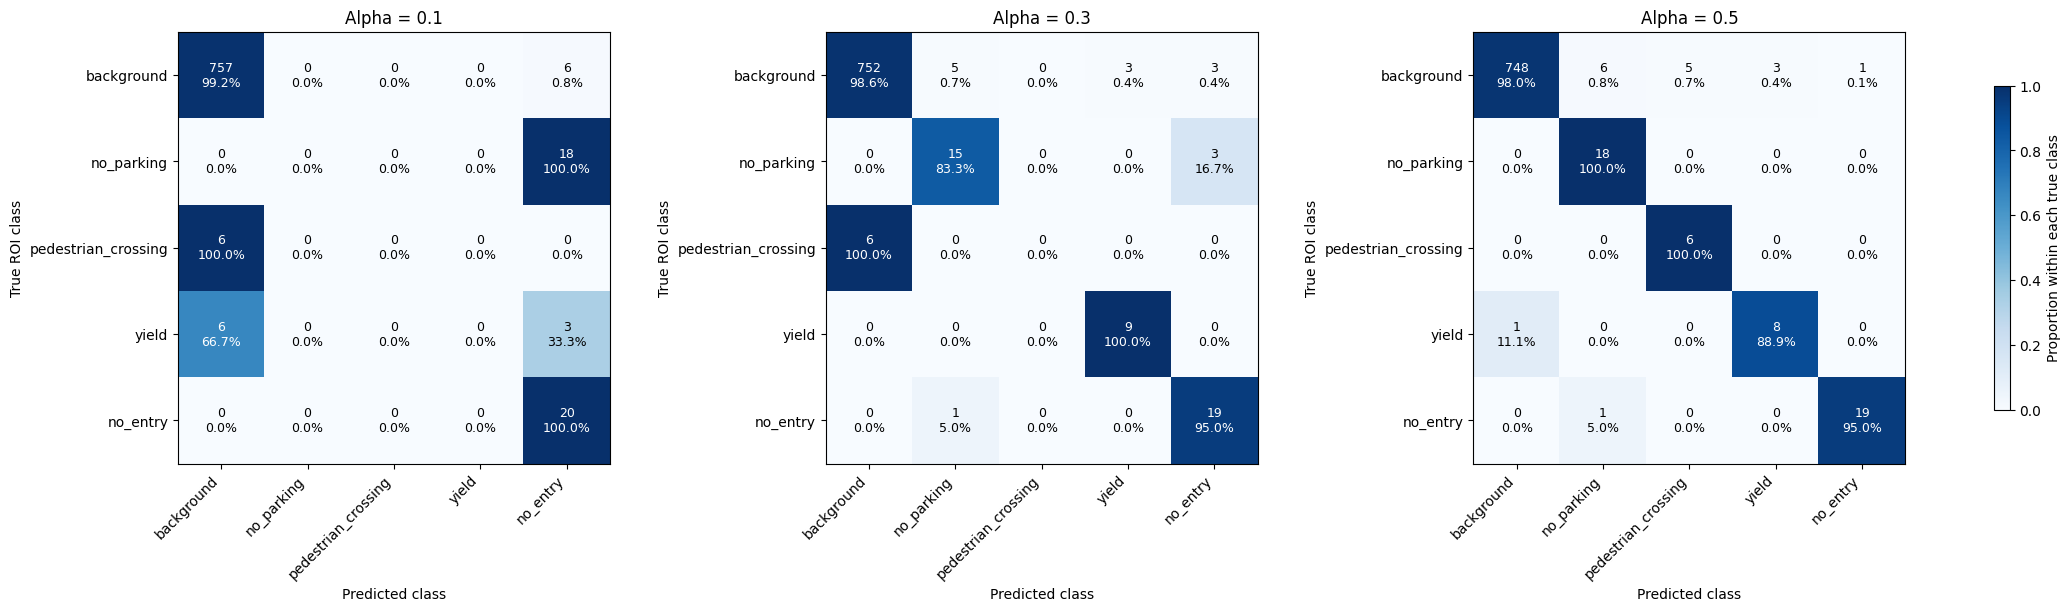

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

alpha_results = torch.load(f"{saving_dir}/alpha_confusion_results.pt", map_location="cpu", weights_only=True)
#alpha_results = torch.load(output_path, map_location="cpu", weights_only=True)
alpha_results = sorted(alpha_results, key=lambda result: result["alpha"])

summary_rows = []
class_rows = []

for result in alpha_results:
    matrix = np.asarray(result["confusion_matrix"], dtype=np.int64)

    # Give each foreground class equal weight.
    sign_f1 = [
        row["f1"]
        for row in result["per_class"][1:]
        if row["f1"] is not None
    ]

    summary_rows.append({
        "Alpha": result["alpha"],
        "Best epoch": result["best_epoch"],
        "Val loss (unweighted)": result["loss"],
        "ROI accuracy": result["roi_accuracy"],
        "Sign ROI accuracy": result["foreground_roi_accuracy"],
        "Sign macro F1": np.mean(sign_f1) if sign_f1 else np.nan,
        "Background → sign": int(matrix[0, 1:].sum()),
        "Sign → background": int(matrix[1:, 0].sum()),
        "ROIs": int(matrix.sum()),
    })

    for row in result["per_class"]:
        class_rows.append({
            "Alpha": result["alpha"],
            "Class": row["class"],
            "ROIs": row["support_roi"],
            "Precision": row["precision"],
            "Recall": row["recall"],
            "F1": row["f1"],
        })

# Rank models by foreground macro F1.
summary_df = pd.DataFrame(summary_rows).sort_values(
    "Sign macro F1", ascending=False, na_position="last"
)

display(
    summary_df.style
    .format({
        "Alpha": "{:.1f}",
        "Best epoch": "{:.0f}",
        "Val loss (unweighted)": "{:.5f}",
        "ROI accuracy": "{:.2%}",
        "Sign ROI accuracy": "{:.2%}",
        "Sign macro F1": "{:.2%}",
        "Background → sign": "{:,}",
        "Sign → background": "{:,}",
        "ROIs": "{:,}",
    }, na_rep="N/A")
    .background_gradient(
        subset=["ROI accuracy", "Sign ROI accuracy", "Sign macro F1"],
        cmap="RdYlGn", vmin=0, vmax=1,
    )
    .set_caption("Alpha comparison — validation")
    .hide(axis="index")
)

# Show class-level scores, including background.
per_class_df = pd.DataFrame(class_rows)

display(
    per_class_df.style
    .format({
        "Alpha": "{:.1f}",
        "ROIs": "{:,}",
        "Precision": "{:.2%}",
        "Recall": "{:.2%}",
        "F1": "{:.2%}",
    }, na_rep="N/A")
    .background_gradient(
        subset=["Precision", "Recall", "F1"],
        cmap="RdYlGn", vmin=0, vmax=1,
    )
    .set_caption("Scores per class — validation")
    .hide(axis="index")
)

# Show counts and row-normalized percentages.
fig, axes = plt.subplots(
    1, len(alpha_results),
    figsize=(7 * len(alpha_results), 6),
    squeeze=False,
    constrained_layout=True,
)

for ax, result in zip(axes.ravel(), alpha_results):
    matrix = np.asarray(result["confusion_matrix"], dtype=np.int64)
    support = matrix.sum(axis=1, keepdims=True)

    normalized = np.divide(
        matrix, support,
        out=np.zeros_like(matrix, dtype=float),
        where=support != 0,
    )

    heatmap = ax.imshow(normalized, cmap="Blues", vmin=0, vmax=1)
    names = result["class_names"]

    for row in range(len(names)):
        for column in range(len(names)):
            percentage = (
                f"{normalized[row, column]:.1%}"
                if support[row, 0] else "N/A"
            )
            ax.text(
                column, row,
                f"{matrix[row, column]}\n{percentage}",
                ha="center", va="center",
                color="white" if normalized[row, column] > 0.5 else "black",
                fontsize=9,
            )

    ax.set(
        title=f"Alpha = {result['alpha']:g}",
        xlabel="Predicted class",
        ylabel="True ROI class",
        xticks=range(len(names)),
        yticks=range(len(names)),
        xticklabels=names,
        yticklabels=names,
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

fig.colorbar(
    heatmap, ax=axes.ravel().tolist(),
    label="Proportion within each true class",
    shrink=0.75,
)
plt.show()

### Alpha Results and Final Validation Choice

All three classifiers are evaluated on **816 ROIs: 763 background and 53 sign ROIs**. The stored results select **alpha 0.5**:

| Alpha | Best epoch | Unweighted validation loss | Sign ROI accuracy | Sign macro F1 | Background → sign |
| --- | --- | --- | --- | --- | --- |
| 0.1 | 48 | 0.10948 | 37.74% | 14.93% | 6 |
| 0.3 | 50 | 0.08797 | 81.13% | 61.77% | 11 |
| **0.5** | **50** | **0.07365** | **96.23%** | **82.33%** | **15** |

Alpha 0.1 predicts only background or `no_entry` in the displayed matrix and fails to recognize the other three sign classes. Alpha 0.3 improves most classes but classifies all six `pedestrian_crossing` ROIs as background. Alpha 0.5 correctly classifies **18/18 no-parking**, **6/6 pedestrian-crossing**, **8/9 yield**, and **19/20 no-entry** ROIs: **51/53** sign ROIs in total.

For alpha 0.5, the two foreground errors are one yield ROI rejected as background and one no-entry ROI predicted as no-parking. There are also 15 background-to-sign errors. `no_entry` reaches **95.00% F1**, while `pedestrian_crossing` has **100.00% ROI recall** but only **54.55% precision**, showing that false-positive predictions remain relevant.

Compared with the chosen inverse-frequency NMS-grid run, the retrained alpha 0.5 classifier increases macro F1 from **75.01% to 82.33%** and reduces background-to-sign errors from **31 to 15**, at the cost of two sign-ROI errors. It is exported at its best recorded epoch, **50**. These are single-run validation results on small per-class ROI supports.

## 12. Export the Selected Model and Define Test Evaluation

Select the **alpha 0.5** record from `list_faster_rcnn_alpha.pt` and save it as `/kaggle/working/my_faster_rcnn.pt`. The exported dictionary includes the best detector/CNN weights, configuration, class ordering, class weights, and training histories. A download link is generated for this file.

The cell displays the saved class weights and weighted train/validation loss curves, marking the selected epoch. It then restores the same checkpoint and calls `evaluate_classifier` on a loader built from `data_test` and `test_labels`, without further training or parameter selection.

Test metrics and the full matrix are saved in `final_metrics.pt`. The `selected_classes` list contains all four sign categories, so its summary includes `no_entry`. These remain ROI classification metrics.


Saved checkpoint: /kaggle/working/my_faster_rcnn.pt


/kaggle/working/my_faster_rcnn.pt

Class,Loss weight
background,0.4618
no_parking,3.4460
pedestrian_crossing,4.8734
yield,4.0825
no_entry,2.8255


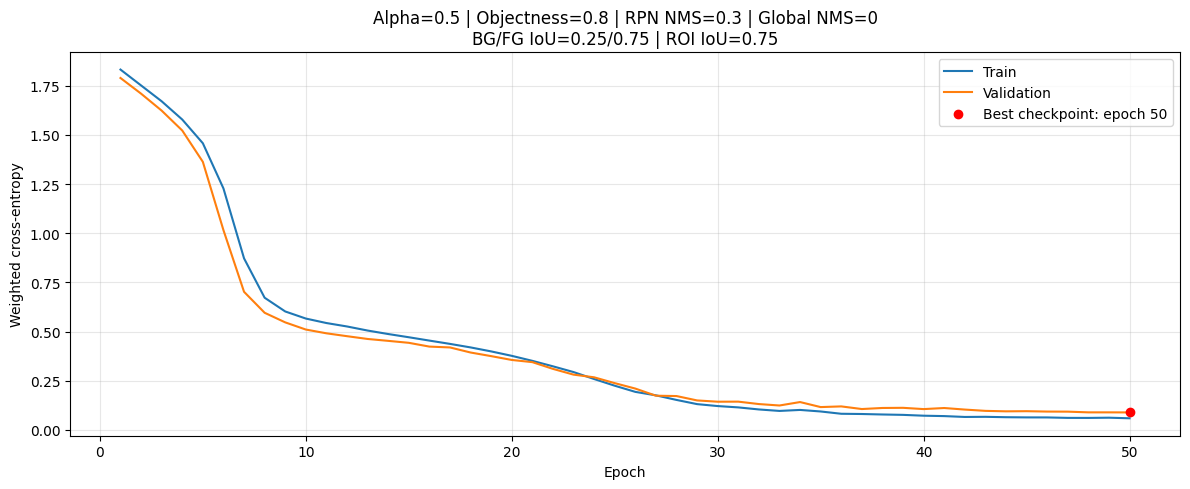

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 226MB/s]  


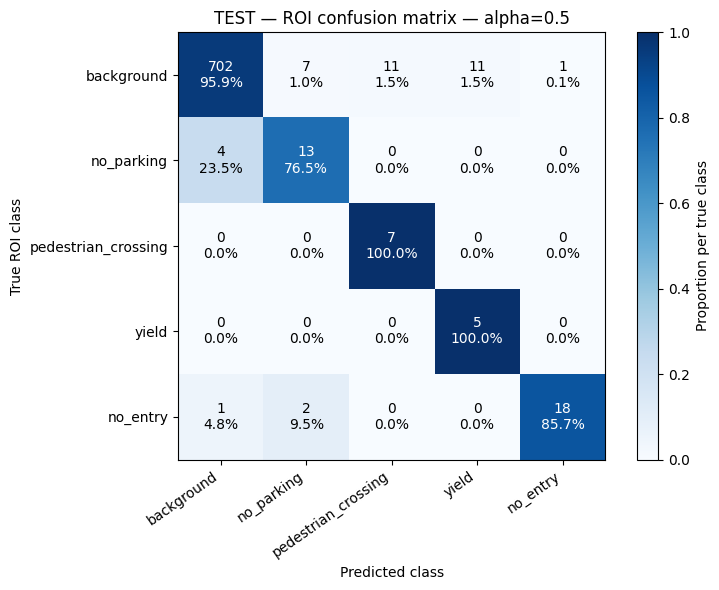

class,support_roi,precision,recall,f1
no_parking,17,59.09%,76.47%,66.67%
pedestrian_crossing,7,38.89%,100.00%,56.00%
yield,5,31.25%,100.00%,47.62%
no_entry,21,94.74%,85.71%,90.00%


Alpha,Test images,"Test loss (all ROIs, unweighted)",Selected sign ROIs,Correct sign ROIs,Sign ROI accuracy,Sign macro F1
0.5,70,0.20435,50,43,86.00%,65.07%


In [10]:
import gc
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from torchvision import transforms
from torch.utils.data import DataLoader
from IPython.display import display, FileLink

models_path = Path(f"{saving_dir}/list_faster_rcnn_alpha.pt")
#models_path = Path("/kaggle/working/list_faster_rcnn_alpha.pt")
output_dir = Path("/kaggle/working")
output_dir.mkdir(parents=True, exist_ok=True)
checkpoint_path = output_dir / "my_faster_rcnn.pt"

# Extract the alpha=0.5 model from the original list.
records = torch.load(
    models_path, map_location="cpu", weights_only=True
)
matches = [
    record for record in records
    if abs(float(record["alpha"]) - 0.5) < 1e-8
    and record.get("checkpoints")
]
if len(matches) != 1:
    raise ValueError("Expected exactly one completed alpha=0.5 checkpoint.")

saved = matches[0]
del records, matches

# Save best weights, parameters, and loss histories together.
torch.save(saved, checkpoint_path)
print(f"Saved checkpoint: {checkpoint_path}")
display(FileLink(os.path.relpath(checkpoint_path)))

# Display the saved loss weights.
display(
    pd.DataFrame({
        "Class": saved["class_names"],
        "Loss weight": saved["class_weights"],
    }).style.format({"Loss weight": "{:.4f}"}).hide(axis="index")
)

# Plot training histories and the selected checkpoint.
fig, ax = plt.subplots(figsize=(12, 5))

for key, label in [
    ("cnn_train_losses", "Train"),
    ("cnn_validation_losses", "Validation"),
]:
    values = saved[key]
    ax.plot(range(1, len(values) + 1), values, label=label)

best_epoch = int(saved["best_epoch"])
ax.scatter(
    best_epoch,
    saved["cnn_validation_losses"][best_epoch - 1],
    color="red", zorder=3,
    label=f"Best checkpoint: epoch {best_epoch}",
)
ax.set(
    title=(
        f"Alpha={saved['alpha']:g} | Objectness={saved['objectness_thresh']:g}"
        f" | RPN NMS={saved['nms_thresh']:g}"
        f" | Global NMS={saved['global_nms_threshold']:g}\n"
        f"BG/FG IoU={saved['bg_iou']:g}/{saved['fg_iou']:g}"
        f" | ROI IoU={saved['roi_iou_threshold']:g}"
    ),
    xlabel="Epoch",
    ylabel="Weighted cross-entropy",
)
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

# Evaluate the selected checkpoint on TEST.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

test_dataset = Traffic_sign(
    data_test, test_labels, transform=transforms.ToTensor()
)
test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    collate_fn=collate_fn,
)

model = load_classifier_checkpoint(saved, device)
try:
    metrics = evaluate_classifier(
        model,
        test_loader,
        saved["class_names"],
        description="TEST — alpha=0.5",
        class_weights=saved.get("class_weights"),
        show_progress=True,
    )
finally:
    del model
    gc.collect()
    if device.type == "cuda":
        torch.cuda.empty_cache()

# Save test results without duplicating model weights.
selected_classes = ["no_parking", "pedestrian_crossing", "yield", "no_entry"]

test_result = {
    key: value for key, value in saved.items()
    if key != "checkpoints"
}
test_result.update(metrics)
test_result.update(split="test", reported_classes=selected_classes)
torch.save(test_result, output_dir / "final_metrics.pt")

# Display the complete TEST confusion matrix.
names = saved["class_names"]
matrix = np.asarray(metrics["confusion_matrix"], dtype=np.int64)
support = matrix.sum(axis=1, keepdims=True)
normalized = np.divide(
    matrix, support,
    out=np.zeros_like(matrix, dtype=float),
    where=support != 0,
)

fig, ax = plt.subplots(figsize=(8, 6))
heatmap = ax.imshow(normalized, cmap="Blues", vmin=0, vmax=1)

for row in range(len(names)):
    for column in range(len(names)):
        percent = (
            f"{normalized[row, column]:.1%}"
            if support[row, 0] else "N/A"
        )
        ax.text(
            column, row, f"{matrix[row, column]}\n{percent}",
            ha="center", va="center",
            color="white" if normalized[row, column] > 0.5 else "black",
        )

ax.set(
    xticks=range(len(names)), yticks=range(len(names)),
    xticklabels=names, yticklabels=names,
    xlabel="Predicted class", ylabel="True ROI class",
    title="TEST — ROI confusion matrix — alpha=0.5",
)
plt.setp(ax.get_xticklabels(), rotation=35, ha="right")
fig.colorbar(heatmap, ax=ax, label="Proportion per true class")
fig.tight_layout()
plt.show()

# Keep scores calculated from the FULL matrix; report three sign classes.
scores = pd.DataFrame(metrics["per_class"])
scores = scores[scores["class"].isin(selected_classes)].copy()

display(
    scores.style.format({
        "support_roi": "{:.0f}",
        "precision": "{:.2%}",
        "recall": "{:.2%}",
        "f1": "{:.2%}",
    }, na_rep="N/A")
    .set_caption("TEST — selected sign classes")
    .hide(axis="index")
)

ids = [names.index(name) for name in selected_classes]
count = int(matrix[ids, :].sum())
correct = int(matrix.diagonal()[ids].sum())

summary = pd.DataFrame([{
    "Alpha": saved["alpha"],
    "Test images": metrics["image_count"],
    "Test loss (all ROIs, unweighted)": metrics["loss"],
    "Selected sign ROIs": count,
    "Correct sign ROIs": correct,
    "Sign ROI accuracy": correct / count if count else np.nan,
    "Sign macro F1": scores["f1"].mean(),
}])

display(
    summary.style.format({
        "Alpha": "{:.1f}",
        "Test loss (all ROIs, unweighted)": "{:.5f}",
        "Sign ROI accuracy": "{:.2%}",
        "Sign macro F1": "{:.2%}",
    }, na_rep="N/A")
    .set_caption("TEST — three-class summary")
    .hide(axis="index")
)

## 13. Predict from a List of Images

`predict_image_list(model, images, score_threshold)` separates inference from visualization. It processes each tensor image with the loaded model, obtains proposals and pooled features, and computes CNN softmax scores without using annotations.

The return value contains one list per input image. Each prediction is stored as:

`[x1, y1, x2, y2, class_id, probability]`

Coordinates are rescaled to the original image dimensions. Background predictions and scores below the supplied threshold are removed; images with no retained predictions receive an empty list. The method accepts an image list but processes its images sequentially.

In [19]:
@torch.inference_mode()
def predict_image_list(model, images, score_threshold=0.0):
    model.eval()
    model_device = next(model.parameters()).device
    all_predictions = []

    for image in images:
        features, proposals, _, image_sizes = model.get_proposals(
            [image.to(model_device)], targets=None
        )
        boxes = proposals[0]

        if len(boxes) == 0:
            all_predictions.append([])
            continue

        roi_features = model.detector.roi_align(
            features, proposals, image_sizes
        )
        probabilities = model.main(roi_features).softmax(dim=1)
        scores, labels = probabilities.max(dim=1)

        keep = (labels != 0) & (scores >= score_threshold)

        height, width = image.shape[-2:]
        resized_height, resized_width = image_sizes[0]
        scale = boxes.new_tensor([
            width / resized_width, height / resized_height,
            width / resized_width, height / resized_height,
        ])

        final_boxes = (boxes[keep] * scale).cpu().tolist()
        final_labels = labels[keep].cpu().tolist()
        final_scores = scores[keep].cpu().tolist()

        image_preds = []
        for box, label, score in zip(final_boxes, final_labels, final_scores):
            # Format: [x1, y1, x2, y2, class_id, probability]
            image_preds.append([box[0], box[1], box[2], box[3], label, score])
        
        all_predictions.append(image_preds)

    return all_predictions

### Visualize the Exported Model on Test Images

Load `my_faster_rcnn.pt` once and inspect every fifth image of `dataset_test`. Ground-truth boxes are shown in green; predictions are shown in red with their class and softmax score.

`score_threshold = 0.0` displays all proposals whose predicted class is not background. The saved RPN/objectness/NMS settings still apply. Annotations are used only for the ground-truth panel, not to generate predictions.

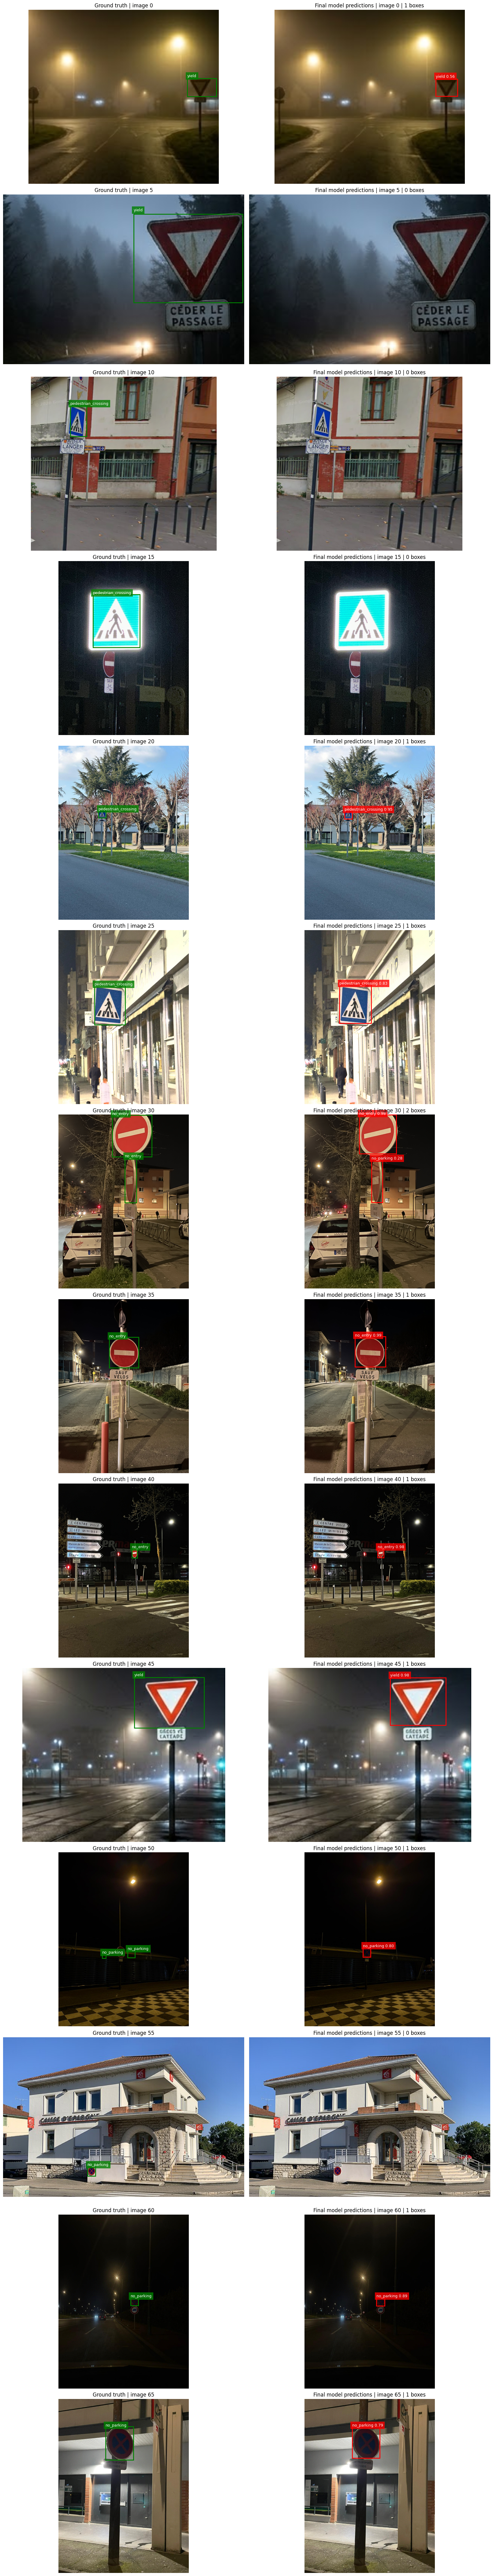

In [29]:
import gc
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from pathlib import Path


dataset_test = Traffic_sign(data_test, test_labels, transform=transforms.ToTensor())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_path = Path(f"{saving_dir}/my_faster_rcnn.pt")
#model_path = Path("/kaggle/working/my_faster_rcnn.pt")

score_threshold = 0.0
dataset = dataset_test  
image_indices = list(np.arange(0,len(dataset),5))  

if not image_indices:
    raise ValueError("image_indices must contain at least one index.")

if not model_path.is_file():
    raise FileNotFoundError(f"Checkpoint not found: {model_path}")

checkpoint = torch.load(
    model_path, map_location="cpu", weights_only=True
)
class_names = checkpoint["class_names"]

def draw_ground_truth(ax, image, boxes, labels, color):
    ax.imshow(image.permute(1, 2, 0).numpy())
    ax.axis("off")
    for box, label in zip(boxes.tolist(), labels.tolist()):
        x1, y1, x2, y2 = box
        ax.add_patch(Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            fill=False, edgecolor=color, linewidth=2,
        ))
        ax.text(
            x1, max(0, y1 - 3), class_names[label],
            color="white", fontsize=9,
            bbox=dict(facecolor=color, alpha=0.8, edgecolor="none"),
        )

def draw_predictions(ax, image, predictions, color):
    ax.imshow(image.permute(1, 2, 0).numpy())
    ax.axis("off")
    for pred in predictions:
        x1, y1, x2, y2, label, score = pred
        ax.add_patch(Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            fill=False, edgecolor=color, linewidth=2,
        ))
        text = f"{class_names[label]} {score:.2f}"
        ax.text(
            x1, max(0, y1 - 3), text,
            color="white", fontsize=9,
            bbox=dict(facecolor=color, alpha=0.8, edgecolor="none"),
        )


model = load_classifier_checkpoint(checkpoint, device)

# Préparation de la liste d'images pour le traitement par lots
images_list = []
targets_list = []

for idx in image_indices:
    img, ann = dataset[idx]
    img = img.detach().cpu()
    images_list.append(img)
    targets_list.append(prepare_targets([img], [ann])[0])

fig, axes = plt.subplots(
    len(image_indices), 2,
    figsize=(16, 6 * len(image_indices)),
    squeeze=False,
    constrained_layout=True,
)

try:
    # Appel unique de la méthode pour générer toutes les prédictions
    batch_predictions = predict_image_list(model, images_list, score_threshold)

    for row, (image, target, predictions, img_idx) in enumerate(zip(images_list, targets_list, batch_predictions, image_indices)):
        
        draw_ground_truth(
            axes[row, 0], image,
            target["boxes"], target["labels"],
            color="green",
        )
        axes[row, 0].set_title(
            f"Ground truth | image {img_idx}"
        )

        draw_predictions(
            axes[row, 1], image,
            predictions,
            color="red"
        )
        axes[row, 1].set_title(
            f"Final model predictions | image {img_idx} | {len(predictions)} boxes"
        )

finally:
    del model
    gc.collect()
    if device.type == "cuda":
        torch.cuda.empty_cache()

plt.show()

### Qualitative Test Observations

The saved figure shows successful detections as well as missed annotated signs. In image **0**, the model predicts the yield sign with a displayed softmax score of **0.56**. In images **35** and **40**, it predicts the no-entry signs, with scores **0.99** and **0.98** respectively.

Image **5** contains an annotated yield sign but has **no retained prediction**. The visualization alone cannot determine whether that miss originates from proposal generation, filtering, or classification. It illustrates why good classification scores on retained ROIs do not guarantee that every annotated sign is detected.

These examples support qualitative inspection of the selected model. They do not establish an object-level precision, recall, or mAP for the full test set.

## 14. Conclusions and Saved Artifacts

The experiment first improved anchor objectness through RPN fine-tuning, then compared proposal filtering and classifier weighting. The selected model uses **objectness 0.8**, **RPN NMS 0.3**, **global NMS 0.0**, **BG/FG IoU 0.25/0.75**, **ROI IoU 0.75**, and **alpha 0.5**.

Its stored validation result is **82.33% sign macro F1**, with **51 correctly classified sign ROIs out of 53**. This is evidence for the chosen classifier configuration on the available proposals, not a complete-pipeline detection score. The test examples show both successful predictions and missed annotated signs. Quantitative evaluation of all annotated objects would additionally require matching final predictions to ground-truth boxes and accounting for unmatched objects.

| Artifact | Contents |
| --- | --- |
| `rpnS_finetuned.pt` | Fine-tuned RPN configurations, best weights, and histories. |
| `My_Best_rpn.pt` | The two exported RPN candidate dictionaries. |
| `list_faster_rcnn_global_weighted.pt` | Completed NMS-grid model dictionaries and best full-model checkpoints. |
| `classifier_results_with_confusion.pt` | NMS validation matrices, settings, and saved losses, without weights. |
| `list_faster_rcnn_alpha.pt` | Alpha configurations, best full-model weights, and histories. |
| `alpha_confusion_results.pt` | Alpha validation matrices and metrics, without weights. |
| `my_faster_rcnn.pt` | The single exported alpha 0.5 model dictionary. |
| `final_metrics.pt` | Test-evaluation metrics and settings written by the test cell, without weights. |

Full classifier checkpoints contain both detector and CNN weights. Thresholds and class ordering are stored separately in the same dictionary and must be restored alongside the weights.